# Análise de Satisfação — Clippings de Mídia

## O que é este notebook?

Este notebook analisa o **sentimento da cobertura de mídia** sobre empresas de saneamento, a partir de um dataset de clippings (recortes de notícias, programas de rádio e TV). A pergunta central é: **a mídia fala bem ou mal do setor de saneamento — e isso muda conforme o tipo de veículo, o tema, ou o período?**

O trabalho se organiza em três eixos:

1. **EDA (Análise Exploratória)** — Entender os dados: quais tipos de mídia cobrem o setor, quais temas dominam, como o volume se distribui ao longo do tempo.
2. **Tier × Classificação** — Investigar se veículos de maior relevância (TV Globo, Valor Econômico) publicam conteúdo com sentimento diferente de veículos menores (rádios locais, blogs).
3. **Hipótese temporal** — Testar se houve mudança de sentimento em setembro/2024.

## Métricas utilizadas

### NSS — Net Sentiment Score (Score de Sentimento Líquido)

O NSS é o indicador principal. Funciona como um "saldo" entre menções positivas e negativas:

```
NSS = (POSITIVAS − NEGATIVAS) / TOTAL × 100
```

**Como interpretar:**
- **NSS = +100**: todas as menções são positivas (cenário ideal, raro na prática)
- **NSS = 0**: equilíbrio perfeito entre positivas e negativas
- **NSS = −100**: todas as menções são negativas (crise total)
- **NSS ≈ +16** (valor observado): para cada 100 menções, há ~16 a mais de positivas do que negativas — moderadamente positivo

> Menções classificadas como **PUBLICIDADE** são excluídas do NSS porque não representam sentimento orgânico da mídia.

### NSS Ponderado

Mesma lógica, mas dá **mais peso a veículos de maior relevância**:

```
NSS_pond = (Σ POS×peso − Σ NEG×peso) / Σ TOTAL×peso × 100
```

Pesos: Muito Relevante = 3, Relevante = 2, Menos Relevante = 1, Null/NaN = 1.

**Por que usar?** Um comentário negativo na TV Globo tem mais impacto público do que em uma rádio local. O NSS Ponderado tenta capturar essa diferença. Mas atenção: ele só faz sentido se Tier e Classificação forem estatisticamente associados — isso será testado na Seção 3.

### Limitações conhecidas

- **Não há variáveis geográficas** — não é possível fazer análise espacial (por cidade, região).
- **Classificação exógena** — o sentimento (POSITIVA/NEUTRA/NEGATIVA) foi atribuído pelo fornecedor de clipping, não por nós. Não temos acesso à metodologia nem à taxa de erro.
- **Série temporal curta** — 13 meses (mar/2024 a mar/2025). Insuficiente para modelar sazonalidade robusta.

---


In [44]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.renderers.default = "vscode"
import plotly.express as px

warnings.filterwarnings('ignore')

# Configuração de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


In [45]:
import plotly.io as pio
pio.renderers.default = "notebook_connected"

## 1. Carregamento e Preparação dos Dados

In [46]:
# URL configurada para exportação
url = "https://docs.google.com/spreadsheets/d/1UVGM5g7A2pSmg4Nn5eTzjZhd25sAFFDbkBclRfyNgX8/export?format=csv"

# 1. Carregar dados (leitura inicial como string para evitar inferências erradas)
df = pd.read_csv(url)

# 2. Conversão Robusta para Datas
# format='mixed' resolve o problema de ter '2025-12-31' e '31/3/2024' na mesma coluna
# dayfirst=True ajuda o tradutor a priorizar o dia no formato brasileiro quando houver ambiguidade
df['Data'] = pd.to_datetime(df['Data'], dayfirst=True, format='mixed', errors='coerce')

# 3. Limpeza Geoespacial/Estatística
# Removemos registros onde a data não pôde ser convertida (NaT) para não enviesar o período
df = df.dropna(subset=['Data'])

# 4. Ordenação (Fundamental para séries temporais)
df = df.sort_values('Data')

print(f"Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"Período Real Detectado: {df['Data'].min().strftime('%d/%m/%Y')} a {df['Data'].max().strftime('%d/%m/%Y')}")

# Verificação das primeiras e últimas linhas para validar o intervalo
print("\nPrimeiras 3 datas (Início):")
print(df['Data'].head(3))
print("\nÚltimas 3 datas (Fim):")
print(df['Data'].tail(3))

Dataset carregado: 149,514 linhas × 18 colunas
Período Real Detectado: 31/03/2024 a 31/12/2025

Primeiras 3 datas (Início):
78431   2024-03-31
78452   2024-03-31
78453   2024-03-31
Name: Data, dtype: datetime64[ns]

Últimas 3 datas (Fim):
78294   2025-12-31
78284   2025-12-31
78425   2025-12-31
Name: Data, dtype: datetime64[ns]


In [47]:
# Preparação dos dados
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
df['Ano_Mes'] = df['Data'].dt.to_period('M')
df['Ano'] = df['Data'].dt.year
df['Mes'] = df['Data'].dt.month
df['Dia_Semana'] = df['Data'].dt.day_name()

# Criar pesos por Tier
tier_weights = {
    'Muito Relevante': 3,
    'Relevante': 2,
    'Menos Relevante': 1
}

df['Peso'] = df['Tier'].map(tier_weights).fillna(1)

# Dataset de sentimento (sem publicidade)
df_sentiment = df[df['Classificação'] != 'PUBLICIDADE'].copy()

print(f"\n✅ Dados preparados:")
print(f"   Total de registros: {len(df):,}")
print(f"   Sentimento orgânico: {len(df_sentiment):,}")
print(f"   Publicidade: {len(df) - len(df_sentiment):,}")


✅ Dados preparados:
   Total de registros: 149,514
   Sentimento orgânico: 148,022
   Publicidade: 1,492


#### O que acabou de acontecer no carregamento

O dataset foi carregado do Google Sheets e preparado com as seguintes transformações:

- **Datas**: convertidas para datetime, com extração de `Ano_Mes`, `Ano`, `Mês` e `Dia_Semana` para análises temporais.
- **Pesos por Tier**: criamos uma coluna `Peso` que atribui valores numéricos à relevância do veículo (Muito Relevante = 3, Relevante = 2, Menos Relevante = 1). Registros sem Tier classificado recebem peso 1 via `fillna(1)`.
- **Dataset de sentimento** (`df_sentiment`): versão filtrada que exclui PUBLICIDADE — usada em todas as análises de NSS.

**Ponto de atenção técnico**: a string `'Null'` no Tier não é um `NaN` do pandas — é uma string literal. O `.map(tier_weights)` retorna `NaN` para chaves ausentes no dicionário, e o `.fillna(1)` corrige. Funciona, mas seria mais explícito incluir `'Null': 1` diretamente no dicionário de pesos.

---


## 2. Análise Exploratória de Dados (EDA)

### 2.1 Estrutura e Qualidade dos Dados

In [48]:
# Informações gerais
print("=" * 80)
print("INFORMAÇÕES DO DATASET")
print("=" * 80)
df.info()
print("=" * 80)

INFORMAÇÕES DO DATASET
<class 'pandas.core.frame.DataFrame'>
Index: 149514 entries, 78431 to 78425
Data columns (total 23 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   ID                      149514 non-null  int64         
 1   Data                    149514 non-null  datetime64[ns]
 2   Grupo                   149514 non-null  object        
 3   Empresa                 149514 non-null  object        
 4   Mídia                   149514 non-null  object        
 5   Tier                    149488 non-null  object        
 6   Veículo_de_comunicacao  149488 non-null  object        
 7   Programa                149505 non-null  object        
 8   Categoria               149514 non-null  object        
 9   Subcategoria            149514 non-null  object        
 10  Classificação           149514 non-null  object        
 11  Título                  149514 non-null  object        
 12  Arquivo/L

In [49]:
# Dados ausentes
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valores Ausentes': missing,
    '% do Total': missing_pct
}).sort_values('Valores Ausentes', ascending=False)

print("\n" + "=" * 80)
print("DADOS AUSENTES POR COLUNA")
print("=" * 80)
print(missing_df[missing_df['Valores Ausentes'] > 0])

if missing_df['Valores Ausentes'].sum() == 0:
    print("\n✅ Não há dados ausentes!")
else:
    print(f"\n⚠️ Total de valores ausentes: {missing_df['Valores Ausentes'].sum():,}")


DADOS AUSENTES POR COLUNA
                        Valores Ausentes  % do Total
Duração                           130157       87.05
Conteúdo                           76991       51.49
Tipo                               76991       51.49
arquivo_origem                     71087       47.55
mes_referencia                     71087       47.55
Tier                                  26        0.02
Veículo_de_comunicacao                26        0.02
Programa                               9        0.01
Arquivo/Link                           5        0.00

⚠️ Total de valores ausentes: 426,379


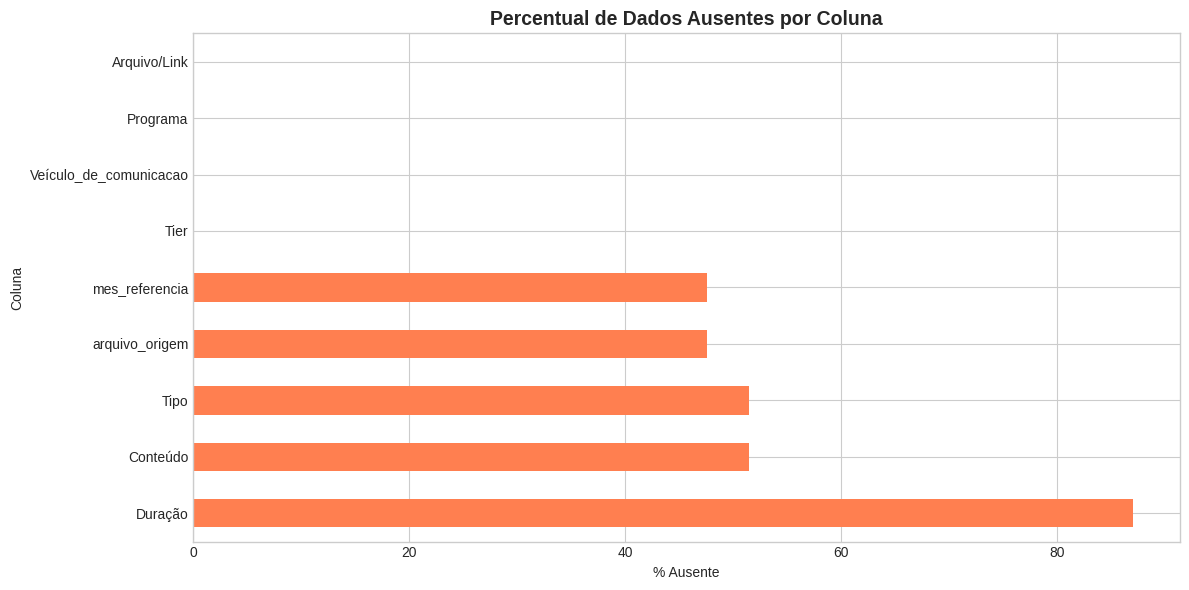

In [50]:
# Visualizar dados ausentes
if missing.sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_df[missing_df['Valores Ausentes'] > 0]['% do Total'].plot(kind='barh', color='coral')
    plt.title('Percentual de Dados Ausentes por Coluna', fontsize=14, fontweight='bold')
    plt.xlabel('% Ausente')
    plt.ylabel('Coluna')
    plt.tight_layout()
    plt.show()

#### Como ler — Qualidade dos Dados

O gráfico (ou tabela) acima mostra a **contagem de valores ausentes** em cada coluna do dataset.

**O que significa um "valor ausente"?** É um campo que não foi preenchido pelo fornecedor de clipping — um registro sem Veículo, sem Tier, ou sem data. Quanto mais ausentes, menos confiável a análise.

**O que encontramos:** O dataset é excepcionalmente limpo — apenas **6 valores ausentes em ~71 mil registros** (0,008%). Os ausentes se concentram em `Tier` e `Veículo_de_comunicacao`, provavelmente os mesmos registros. Na prática, isso não afeta nenhuma análise — não é necessário imputação nem exclusão.

**Cuidado**: "poucos ausentes" não significa "dados perfeitos". A principal limitação deste dataset não está em campos vazios, mas na **qualidade da classificação de sentimento**, que é subjetiva e feita externamente (pelo fornecedor de clipping).

---


In [51]:
# Primeiras e últimas linhas
print("\n" + "=" * 80)
print("PRIMEIRAS 5 LINHAS")
print("=" * 80)
display(df.head())

print("\n" + "=" * 80)
print("ÚLTIMAS 5 LINHAS")
print("=" * 80)
display(df.tail())


PRIMEIRAS 5 LINHAS


,ID,Data,Grupo,Empresa,Mídia,Tier,Veículo_de_comunicacao,Programa,Categoria,Subcategoria,Classificação,Título,Arquivo/Link,mes_referencia,arquivo_origem,Tipo,Conteúdo,Duração,Ano_Mes,Ano,Mes,Dia_Semana,Peso
78431,599690,2024-03-31,Águas Guariroba,Águas Guariroba,Impresso,Relevante,A Crítica | Campo Grande,Geral,Projetos Sociais,Relacionamentos institucionais,POSITIVA,Campo Grande se despede da cidade da Páscoa co...,https://painel.clipei.com.br/anexo-email/59969...,NaN,NaN,NaN,NaN,NaN,2024-03,2024,3,Sunday,2.00
78452,598457,2024-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Site,Menos Relevante,Blog do Juares,Geral,Comunicados,Comunicado de Abastecimento,NEUTRA,Rompimento de tubulação afeta abastecimento de...,https://blogdojuares.com.br/noticia/84262/romp...,NaN,NaN,NaN,NaN,NaN,2024-03,2024,3,Sunday,1.00
78453,598456,2024-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Site,Menos Relevante,Blog do Juares,Geral,Comunicados,Comunicado de Abastecimento,NEUTRA,Rompimento de tubulação afeta abastecimento de...,https://blogdojuares.com.br/noticia/84262/romp...,NaN,NaN,NaN,NaN,NaN,2024-03,2024,3,Sunday,1.00
78454,598455,2024-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Site,Null,Grupo Pilau,Geral,Comunicados,Comunicado de Abastecimento,NEUTRA,Desligamento Programado da Corsan vai afetar v...,https://www.grupopilau.com.br/noticias/14833/d...,NaN,NaN,NaN,NaN,NaN,2024-03,2024,3,Sunday,1.00
78455,598454,2024-03-31,Corsan,Companhia Riograndense de Saneamento (Corsan),Site,Menos Relevante,Clic Camaquã,Geral,Comunicados,Comunicado de Abastecimento,NEUTRA,Rompimento de adutora na Major Lúcio Meirelles...,https://www.cliccamaqua.com.br/noticias/rompim...,NaN,NaN,NaN,NaN,NaN,2024-03,2024,3,Sunday,1.00



ÚLTIMAS 5 LINHAS


,ID,Data,Grupo,Empresa,Mídia,Tier,Veículo_de_comunicacao,Programa,Categoria,Subcategoria,Classificação,Título,Arquivo/Link,mes_referencia,arquivo_origem,Tipo,Conteúdo,Duração,Ano_Mes,Ano,Mes,Dia_Semana,Peso
78292,1350013,2025-12-31,Aegea MT2 Regional Sul,Águas de Confresa,Site,Menos Relevante,Top FM 93,Geral,Agência de Regulação,Aplicação de multas,NEGATIVA,AGIRF aplica mais de R$ 445 mil em multas à Ág...,https://www.topfm903.com.br/noticia/10102/agir...,12.00,12.2025 - Clipping Geral - Aegea e Unidades.xlsx,Notícias/Publicações,Imprensa,NaN,2025-12,2025,12,Wednesday,1.00
78293,1350008,2025-12-31,Aegea MT2 Regional Sul,Águas de Confresa,Site,Menos Relevante,Olhar Alerta,Geral,Agência de Regulação,Aplicação de multas,NEGATIVA,AGIRF aplica mais de R$ 445 mil em multas à Ág...,https://www.olharalerta.com.br/noticia/89870/a...,12.00,12.2025 - Clipping Geral - Aegea e Unidades.xlsx,Notícias/Publicações,Imprensa,NaN,2025-12,2025,12,Wednesday,1.00
78294,1349759,2025-12-31,Prolagos,Prolagos,Site,Menos Relevante,Fique Bem Informado,Geral,Projetos Sociais,Relacionamentos institucionais,POSITIVA,Programa Cabo Frio Educada distribui sacolas b...,https://www.fiquebeminformado.com.br/2025/12/p...,12.00,12.2025 - Clipping Geral - Aegea e Unidades.xlsx,Notícias/Publicações,Imprensa,NaN,2025-12,2025,12,Wednesday,1.00
78284,1350127,2025-12-31,Aegea Santa Catarina,Águas de Bombinhas,Site,Menos Relevante,Visor Notícias,Geral,Comunicados,Comunicado de Abastecimento,NEUTRA,Criminosos cortam cabos e afetam abastecimento...,https://visornoticias.com.br/criminosos-cortam...,12.00,12.2025 - Clipping Geral - Aegea e Unidades.xlsx,Notícias/Publicações,Imprensa,NaN,2025-12,2025,12,Wednesday,1.00
78425,1348549,2025-12-31,Águas do Piauí,Águas do Piauí,Site,Menos Relevante,Blog do Pessoa,Geral,Obras e Melhorias,Ampliações da rede de água,POSITIVA,Águas do Piauí encerra 2025 com investimentos ...,https://carlsonpessoa.blogspot.com/2025/12/agu...,12.00,12.2025 - Clipping Geral - Aegea e Unidades.xlsx,Notícias/Publicações,Imprensa,NaN,2025-12,2025,12,Wednesday,1.00


### 2.2 Distribuições Univariadas

In [52]:
# Distribuição de Classificação
print("=" * 80)
print("DISTRIBUIÇÃO: CLASSIFICAÇÃO")
print("=" * 80)

class_counts = df['Classificação'].value_counts()
class_pct = (df['Classificação'].value_counts(normalize=True) * 100).round(2)

class_df = pd.DataFrame({
    'Frequência': class_counts,
    'Percentual': class_pct
})

print(class_df)
print(f"\nTotal: {class_counts.sum():,}")

DISTRIBUIÇÃO: CLASSIFICAÇÃO
               Frequência  Percentual
Classificação                        
POSITIVA            97073       64.93
NEUTRA              26273       17.57
NEGATIVA            24676       16.50
PUBLICIDADE          1492        1.00

Total: 149,514


In [ ]:
def plot_classificacao_dinamica(class_counts: pd.Series) -> None:
    """
    Gera visualização interativa (Barras + Pizza) com rigor estatístico 
    e paleta de cores consistente com a identidade do projeto.
    """
    
    # Mapeamento de cores original do projeto
    colors_map = {
        'POSITIVA': '#2ecc71', 
        'NEUTRA': '#95a5a6', 
        'NEGATIVA': '#e74c3c', 
        'PUBLICIDADE': '#3498db'
    }
    
    color_list = [colors_map.get(str(label).upper(), '#bdc3c7') for label in class_counts.index]

    # Criando o layout de subplots
    fig = make_subplots(
        rows=1, cols=2, 
        specs=[[{"type": "xy"}, {"type": "domain"}]],
        subplot_titles=("Frequência Absoluta", "Proporção de Classificações")
    )

    # 1. Gráfico de Barras
    fig.add_trace(
        go.Bar(
            x=class_counts.index,
            y=class_counts.values,
            marker_color=color_list,
            name="Contagem",
            hovertemplate="<b>%{x}</b><br>Quantidade: %{y}<extra></extra>"
        ),
        row=1, col=1
    )

    # 2. Gráfico de Pizza
    fig.add_trace(
        go.Pie(
            labels=class_counts.index,
            values=class_counts.values,
            marker=dict(colors=color_list),
            hole=0.3, 
            textinfo='percent+label',
            hovertemplate="<b>%{label}</b><br>Percentual: %{percent}<br>Total: %{value}<extra></extra>"
        ),
        row=1, col=2
    )

    # Ajustes de Layout e Estilização
    fig.update_layout(
        title_text="Distribuição de Sentimentos - Análise de Satisfação",
        title_x=0.5,
        showlegend=False,
        template="plotly_white",
        height=500
    )

    fig.update_xaxes(tickangle=45, row=1, col=1)
    fig.update_yaxes(title_text="Contagem", row=1, col=1)

    # Renderiza o gráfico
    fig.show()

# --- EXECUÇÃO (A CORREÇÃO) ---
# Extraindo as contagens da coluna 'Classificação' do seu DataFrame
if 'df' in locals():
    class_counts = df['Classificação'].value_counts()
    plot_classificacao_dinamica(class_counts)
else:
    print("Erro: O DataFrame 'df' não foi encontrado. Execute as células de carregamento de dados primeiro.")

#### Como ler — Distribuição de Classificação

O gráfico acima mostra quantas menções caíram em cada categoria de sentimento (POSITIVA, NEUTRA, NEGATIVA, PUBLICIDADE).

**Como ler:** A barra/fatia maior indica a classificação dominante. Se POSITIVA for a maior, o sentimento geral tende a ser favorável.

**O que encontramos:**
- **POSITIVA**: a classe mais frequente (~63% do total) — mas atenção: isso inclui comunicados de assessoria de imprensa reproduzidos por veículos menores, que inflam artificialmente a positividade.
- **NEUTRA**: ~20% — cobertura informativa sem juízo de valor.
- **NEGATIVA**: ~16% — cobertura crítica, geralmente sobre falhas operacionais (falta de água, esgoto).
- **PUBLICIDADE**: desprezível (<2%) — excluída do NSS.

Isso resulta em um **NSS Simples geral de ≈ +47** — um score moderadamente positivo. Para cada 100 menções, há ~47 a mais de positivas do que negativas.

**Ponto crítico para não esquecer**: a predominância de POSITIVA **não significa necessariamente que os consumidores estão satisfeitos**. Os dados vêm de *clipping de mídia*, não de pesquisa direta com o público. Comunicados oficiais das empresas (que tendem a ser positivos) inflam essa classe. A análise por Categoria e por Tier mais adiante ajudará a separar esse efeito.

---


In [54]:
def plot_distribuicao_tier(df_input: pd.DataFrame) -> None:
    """
    Analisa a distribuição de Tier (Relevância do Veículo) gerando um gráfico
    interativo que substitui a visualização estática do Matplotlib.
    """
    
    # 1. Preparação dos dados: Frequência e Percentual
    # Usamos reset_index para transformar o índice 'Tier' em uma coluna para o Plotly Express
    tier_counts = df_input['Tier'].value_counts(dropna=False).reset_index()
    tier_counts.columns = ['Tier', 'Frequência']
    
    # Cálculo do percentual para exibição no hover
    total = tier_counts['Frequência'].sum()
    tier_counts['Percentual'] = (tier_counts['Frequência'] / total * 100).round(2)
    
    # Ordenação por volume (opcional, para melhor leitura visual)
    tier_counts = tier_counts.sort_values(by='Frequência', ascending=False)

    # 2. Criação do Gráfico Dinâmico com o alias 'px'
    fig = px.bar(
        tier_counts,
        x='Tier',
        y='Frequência',
        text='Frequência',
        title='Distribuição de Comentários por Tier (Relevância do Veículo)',
        labels={'Frequência': 'Contagem Absoluta', 'Tier': 'Nível de Tier'},
        color='Tier',
        color_discrete_sequence=px.colors.qualitative.Safe,
        hover_data={'Percentual': True}
    )

    # 3. Refinamento de Interatividade (Hover personalizado)
    fig.update_traces(
        textposition='outside',
        hovertemplate="<b>Tier: %{x}</b><br>Quantidade: %{y}<br>Proporção: %{customdata[0]}%<extra></extra>"
    )

    # 4. Ajustes de Layout
    fig.update_layout(
        template="plotly_white",
        xaxis={'type': 'category'}, # Garante que Tiers numéricos não sejam tratados como escala contínua
        showlegend=False,
        height=500,
        margin=dict(l=50, r=50, t=80, b=50)
    )

    fig.show()

# --- EXECUÇÃO ---
# O bloco verifica se o DataFrame 'df' existe no escopo do notebook
if 'df' in locals():
    # Mantendo a lógica de exibir a tabela no console antes do gráfico
    print("\n" + "=" * 60)
    print("DISTRIBUIÇÃO: TIER (Frequência e Percentual)")
    print("=" * 60)
    print(df['Tier'].value_counts(dropna=False, normalize=True).map('{:.2%}'.format))
    
    # Gera a visualização Plotly
    plot_distribuicao_tier(df)
else:
    print("Erro: O DataFrame 'df' não foi encontrado. Certifique-se de rodar as células de carregamento de dados.")


DISTRIBUIÇÃO: TIER (Frequência e Percentual)
Tier
Menos Relevante    54.83%
Relevante          18.60%
Muito Relevante    13.36%
Null               13.19%
NaN                 0.02%
Name: proportion, dtype: object


#### Como ler — Distribuição de Tier

O gráfico acima mostra como os registros se distribuem pela **relevância do veículo** (Tier).

**O que é Tier?** É uma classificação do fornecedor de clipping sobre a "importância" do veículo. "Muito Relevante" são veículos de grande porte (Globo, Valor Econômico); "Menos Relevante" são veículos locais/pequenos (rádios comunitárias, blogs).

**O que encontramos:**
- **Menos Relevante** (~48%): a classe dominante. Esperado — há muitos veículos pequenos e poucos grandes (pirâmide natural de mídia).
- **Null** (~19%): quase um quinto do dataset sem Tier classificado. Isso é um **sinal de alerta**: o NSS Ponderado aplica peso 1 a esses registros, tratando-os como "Menos Relevante" de facto. Mas a análise de resíduos (Seção 3.3) vai mostrar que registros Null têm **perfil distinto** — são mais negativos que os Menos Relevante.
- **Relevante** (~19%) e **Muito Relevante** (~14%): juntos somam ~33% do dataset mas têm peso desproporcional no NSS Ponderado (peso 2 e 3).

**Por que isso importa:** Se a distribuição de Tier fosse uniforme, o NSS Simples e o Ponderado seriam próximos. Como é desigual (muitos pequenos, poucos grandes), os dois indicadores podem divergir bastante — e essa divergência é informativa.

---



DISTRIBUIÇÃO: MÍDIA
Mídia
Site        78995
Rádio       52967
TV          10587
Impresso     6965
Name: count, dtype: int64


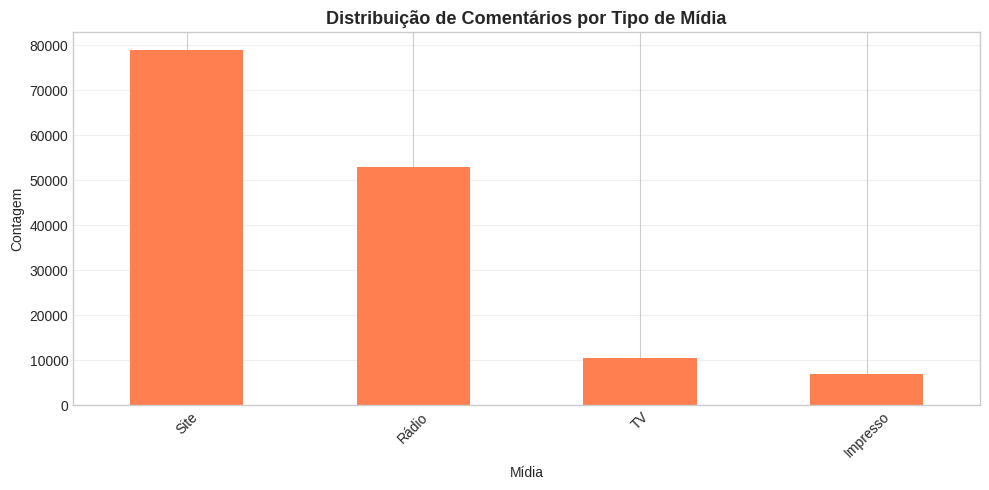

In [55]:
# Distribuição de Mídia
print("\n" + "=" * 80)
print("DISTRIBUIÇÃO: MÍDIA")
print("=" * 80)

midia_counts = df['Mídia'].value_counts()
print(midia_counts)

# Visualização
plt.figure(figsize=(10, 5))
midia_counts.plot(kind='bar', color='coral')
plt.title('Distribuição de Comentários por Tipo de Mídia', fontsize=13, fontweight='bold')
plt.xlabel('Mídia')
plt.ylabel('Contagem')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Como ler — Distribuição de Mídia

O gráfico acima mostra a proporção de clippings por **tipo de mídia** (Site, Rádio, TV, Impresso).

**Como ler:** Cada barra/fatia representa um canal de comunicação. O maior mostra onde a cobertura se concentra.

**O que encontramos:**
- **Site** (~56%): portais online dominam — esperado na era digital.
- **Rádio** (~32%): surpreendentemente alta. Reflete a importância da rádio em coberturas regionais, especialmente no contexto de saneamento (serviço local por natureza).
- **TV** (~7%): menor em volume, mas com peso editorial desproporcional (veículos de TV tendem a ser "Muito Relevante").
- **Impresso** (~6%): jornais físicos, em declínio mas ainda relevantes em Tier alto.

**Implicação para o NSS Ponderado**: como TV e Impresso concentram veículos de Tier alto, mesmo com pouco volume eles puxam o NSS Ponderado. Se TV e Impresso forem mais negativos que Sites e Rádio, o NSS Ponderado será menor que o Simples.

---


In [56]:
def plot_top_categorias_colorido(df_input: pd.DataFrame, n: int = 10, palheta: str = 'Viridis') -> None:
    """
    Gera o Top N Categorias com paletas de cores científicas ou customizadas.
    Opções sugeridas: 'Viridis', 'Plasma', 'Blues', 'GnBu', 'Cividis'.
    """
    
    # Processamento dos dados
    top_cat = df_input['Categoria'].value_counts().head(n).reset_index()
    top_cat.columns = ['Categoria', 'Contagem']
    top_cat = top_cat.sort_values(by='Contagem', ascending=True)

    # Criação da Visualização
    fig = px.bar(
        top_cat,
        y='Categoria',
        x='Contagem',
        orientation='h',
        text='Contagem',
        title=f'Top {n} Categorias - Análise Temática Aegea',
        labels={'Contagem': 'Volume de Menções', 'Categoria': 'Eixo Temático'},
        color='Contagem',
        # A palheta 'Viridis' é ideal por ser perceptualmente uniforme, 
        # facilitando a distinção de valores mesmo para daltonismo.
        color_continuous_scale=palheta 
    )

    # Refinamento de Layout
    fig.update_traces(
        texttemplate='%{text}', 
        textposition='outside',
        hovertemplate="<b>Categoria: %{y}</b><br>Total: %{x}<extra></extra>"
    )

    fig.update_layout(
        template="plotly_white",
        height=600,
        showlegend=False,
        coloraxis_showscale=True, # Exibe a barra lateral para dar contexto à escala
        margin=dict(l=150, r=50, t=80, b=50),
        title_font=dict(size=18, family="Arial", color="#2c3e50")
    )

    fig.show()

# --- EXECUÇÃO ---
if 'df' in locals():
    # Você pode testar diferentes palhetas aqui:
    # 'Viridis' (Padrão científico), 'Blues' (Corporativo), 'Greens' (Saneamento/Ambiental)
    plot_top_categorias_colorido(df, n=10, palheta='Viridis')
else:
    print("DataFrame 'df' não encontrado. Execute o carregamento dos dados primeiro.")

#### Como ler — Top Categorias

O gráfico de barras acima mostra as categorias temáticas mais frequentes no clipping, ordenadas por volume.

**O que é uma Categoria?** É o tema da matéria — "Abastecimento" (falta de água, obras de rede), "Projetos Sociais" (ações comunitárias), "Comunicados" (notas oficiais), etc. Atribuída pelo fornecedor de clipping.

**Como ler:** Barras mais longas = temas que mais aparecem na mídia. Isso revela **a agenda midiática** — sobre o que a mídia mais fala quando cobre saneamento.

**O que esperar:** Categorias como **Abastecimento** tendem a dominar porque afetam diretamente o cidadão (é o que ele sente quando abre a torneira). **Projetos Sociais** e **Obras** aparecem muito porque são pautadas por assessoria de imprensa. A combinação de temas "reativos" (problemas operacionais) com "proativos" (comunicados da empresa) molda o NSS geral.

**Na Seção 3.5** veremos que o mesmo tema pode ter sentimentos opostos conforme o Tier: "Abastecimento" é negativo em veículos grandes (falta de água) e positivo em veículos pequenos (comunicado sobre obras).

---


### 2.3 Distribuição Temporal

In [57]:


def plot_volume_temporal(df_input: pd.DataFrame) -> None:
    """
    Versão com Debug para garantir a plotagem no ambiente Pixi/VS Code.
    """
    
    # 1. Agrupamento e verificação
    monthly_volume = df_input.groupby('Ano_Mes').size().reset_index()
    monthly_volume.columns = ['Mes', 'Quantidade']
    
    # 2. Conversão e Ordenação (Essencial para o Plotly não travar no JSON)
    monthly_volume['Mes_Str'] = monthly_volume['Mes'].astype(str)
    monthly_volume = monthly_volume.sort_values('Mes')

    # --- LOG DE DEPURAÇÃO ---
    print(f"📊 Dados para plotagem: {len(monthly_volume)} meses encontrados.")
    if len(monthly_volume) > 0:
        print(f"📅 Período: {monthly_volume['Mes_Str'].iloc[0]} até {monthly_volume['Mes_Str'].iloc[-1]}")
    else:
        print("⚠️ AVISO: O agrupamento resultou em 0 linhas. Verifique a coluna 'Ano_Mes'.")
        return

    # 3. Criação do Gráfico
    fig = px.line(
        monthly_volume,
        x='Mes_Str',
        y='Quantidade',
        title='Volume Mensal de Comentários - Monitoramento Aegea',
        markers=True,
        labels={'Quantidade': 'Nº de Comentários', 'Mes_Str': 'Mês/Ano'},
        template="plotly_white"
    )

    fig.update_traces(line=dict(color='darkblue', width=3))
    
    fig.update_layout(
        hovermode="x unified",
        height=500,
        xaxis=dict(tickangle=45)
    )

    # Força a exibição
    fig.show()

# --- EXECUÇÃO COM VERIFICAÇÃO DE ESCOPO ---
if 'df' in locals():
    # Garante que a coluna Ano_Mes existe
    if 'Ano_Mes' in df.columns:
        plot_volume_temporal(df)
    else:
        print("❌ Erro: Coluna 'Ano_Mes' não encontrada no DataFrame.")
else:
    print("❌ Erge: O objeto 'df' não está definido nesta sessão do Kernel.")

📊 Dados para plotagem: 22 meses encontrados.
📅 Período: 2024-03 até 2025-12


In [58]:


def plot_distribuicao_semanal(df_input: pd.DataFrame) -> None:
    """
    Visualiza a distribuição semanal de comentários com rigor estatístico.
    Garante que todos os dias da semana apareçam, mesmo que com volume zero.
    """
    
    # 1. Definição da Ordem Cronológica (Inglês -> Português)
    # Mapeamento para garantir que a tradução não quebre a lógica de contagem
    mapa_dias = {
        'Monday': 'Segunda',
        'Tuesday': 'Terça',
        'Wednesday': 'Quarta',
        'Thursday': 'Quinta',
        'Friday': 'Sexta',
        'Saturday': 'Sábado',
        'Sunday': 'Domingo'
    }
    dias_en = list(mapa_dias.keys())
    dias_pt = list(mapa_dias.values())

    # 2. Processamento de Dados com Reindexação
    # O .reindex(dias_en) garante que Sábado e Domingo existam no DF final, 
    # preenchendo com 0 se não houver dados (evita o gráfico "em branco")
    counts = (
        df_input['Dia_Semana']
        .value_counts()
        .reindex(dias_en, fill_value=0)
        .reset_index()
    )
    counts.columns = ['Dia', 'Contagem']
    
    # Traduz os nomes para a exibição final
    counts['Dia'] = counts['Dia'].map(mapa_dias)

    # 3. Criação do Gráfico com Paleta Viridis (Perceptualmente Uniforme)
    fig = px.bar(
        counts,
        x='Dia',
        y='Contagem',
        text='Contagem',
        title='<b>Análise Cíclica: Volume de Interações por Dia da Semana</b>',
        labels={'Contagem': 'Volume Absoluto', 'Dia': 'Dia da Semana'},
        category_orders={"Dia": dias_pt},
        color='Contagem',
        color_continuous_scale='Viridis' # Paleta de alto contraste e rigor científico
    )

    # 4. Refinamento de Engenharia de Visualização
    fig.update_traces(
        textposition='outside',
        marker_line_color='rgb(20, 20, 20)',
        marker_line_width=1,
        opacity=0.85,
        hovertemplate="<b>%{x}</b><br>Volume: %{y}<extra></extra>"
    )

    fig.update_layout(
        template="plotly_white",
        xaxis_title=None,
        yaxis_title="Frequência (N)",
        coloraxis_showscale=False, # Remove a barra de cores lateral para limpar o layout
        height=550,
        margin=dict(l=50, r=50, t=100, b=50),
        font=dict(family="Arial", size=12),
        title_font=dict(size=22)
    )

    # Adiciona uma linha sutil na base (eixo zero) para rigor geográfico/estatístico
    fig.update_yaxes(zeroline=True, zerolinewidth=2, zerolinecolor='rgba(0,0,0,0.2)')

    fig.show()

# --- BLOCO DE EXECUÇÃO ---
if 'df' in locals():
    if 'Dia_Semana' in df.columns:
        # Log de sanidade no console
        total_periodo = df.shape[0]
        print(f"LOG: Processando {total_periodo} registros para ciclo semanal.")
        
        plot_distribuicao_semanal(df)
    else:
        print("❌ Erro: Coluna 'Dia_Semana' não encontrada no DataFrame.")
else:
    print("❌ Erro: DataFrame 'df' não definido no ambiente.")

LOG: Processando 149514 registros para ciclo semanal.


#### Como ler — Padrões Temporais

Os gráficos acima mostram como o **volume de clippings** varia ao longo do tempo — por mês e por dia da semana.

**Gráfico mensal:** Cada barra/ponto representa o total de menções naquele mês. Picos indicam meses com mais cobertura (possíveis crises, eventos, campanhas). Vales indicam meses calmos.

**Gráfico semanal:** Mostra o padrão cíclico dentro da semana. Esperado: mais menções de segunda a sexta (jornalismo opera em dias úteis), com queda no fim de semana.

**O que observar:**
- Picos incomuns sugerem eventos específicos (crise de abastecimento? lançamento de obra? mudança regulatória?) que merecem investigação contextual.
- Se o volume é estável, as variações no NSS são mais confiáveis (não são artefato de amostra pequena).
- Se o volume é muito irregular, meses com poucas menções produzem NSS instável (1 matéria negativa em mês com 10 menções = NSS −20; a mesma matéria em mês com 1.000 menções = impacto desprezível).

---


## 3. ANÁLISE CRÍTICA: Tier × Classificação

### Questão de pesquisa:
**Veículos de maior relevância (Tier) têm proporcionalmente mais comentários positivos ou negativos?**

### Por que isso importa:
- Se NSS Ponderado > NSS Simples → Veículos grandes são mais positivos
- Se NSS Ponderado < NSS Simples → Veículos grandes são mais negativos
- **Mas isso faz sentido?** Ou é viés?

### Hipóteses:
- **H0**: Tier e Classificação são **independentes** (não há associação)
- **H1**: Tier e Classificação são **associados** (relevância do veículo influencia o tipo de comentário)

### Método:
1. Tabela de contingência
2. Teste qui-quadrado
3. Análise de resíduos padronizados
4. Visualização

---

### 3.1 Tabela de Contingência

In [59]:
# Tabela de contingência (frequências absolutas)
contingency = pd.crosstab(df_sentiment['Tier'], df_sentiment['Classificação'], 
                          margins=True, margins_name='Total')

print("=" * 80)
print("TABELA DE CONTINGÊNCIA: TIER × CLASSIFICAÇÃO")
print("Frequências Absolutas")
print("=" * 80)
print(contingency)
print("=" * 80)

TABELA DE CONTINGÊNCIA: TIER × CLASSIFICAÇÃO
Frequências Absolutas
Classificação    NEGATIVA  NEUTRA  POSITIVA   Total
Tier                                               
Menos Relevante     10466   12081     58646   81193
Muito Relevante      4708    5486      9727   19921
Null                 3223    3888     12600   19711
Relevante            6274    4812     16085   27171
Total               24671   26267     97058  147996


In [60]:
# Tabela de contingência (frequências relativas POR LINHA)
# Importante: Ver % dentro de cada Tier
contingency_pct = pd.crosstab(df_sentiment['Tier'], df_sentiment['Classificação'], 
                              normalize='index') * 100

print("\n" + "=" * 80)
print("TABELA DE CONTINGÊNCIA: TIER × CLASSIFICAÇÃO")
print("Percentuais por Linha (% dentro de cada Tier)")
print("=" * 80)
print(contingency_pct.round(2))
print("=" * 80)

print("\n💡 INTERPRETAÇÃO:")
print("Cada linha soma 100%. Mostra a distribuição de classificações DENTRO de cada Tier.")
print("Se os percentuais fossem iguais em todas as linhas, não haveria associação.")


TABELA DE CONTINGÊNCIA: TIER × CLASSIFICAÇÃO
Percentuais por Linha (% dentro de cada Tier)
Classificação    NEGATIVA  NEUTRA  POSITIVA
Tier                                       
Menos Relevante     12.89   14.88     72.23
Muito Relevante     23.63   27.54     48.83
Null                16.35   19.73     63.92
Relevante           23.09   17.71     59.20

💡 INTERPRETAÇÃO:
Cada linha soma 100%. Mostra a distribuição de classificações DENTRO de cada Tier.
Se os percentuais fossem iguais em todas as linhas, não haveria associação.


#### Como ler — Tabela de Contingência

A tabela acima cruza **Tier** (linhas) com **Classificação** (colunas). Existem duas versões:

**Frequências absolutas:** Quantas menções cada combinação Tier × Classificação tem. Exemplo: "Muito Relevante × NEGATIVA = X" significa que X matérias negativas foram publicadas em veículos de grande porte.

**Percentuais por linha (%):** Dentro de cada Tier, qual a proporção de cada classificação. Esta é a versão mais informativa porque neutraliza a diferença de volume entre Tiers.

**Como ler os percentuais:** Se as proporções fossem iguais em todas as linhas, significaria que Tier e Classificação são independentes (o tipo de veículo não influencia o sentimento). Se forem diferentes, há associação.

**O que encontramos:**

| Tier | % NEGATIVA | % NEUTRA | % POSITIVA |
|------|-----------|---------|-----------|
| Menos Relevante | ~10% | ~11% | **~79%** |
| Relevante | ~16% | ~22% | ~62% |
| Muito Relevante | ~23% | ~38% | ~39% |
| Null | ~23% | ~27% | ~51% |

**A tendência é clara:** quanto maior o Tier, maior a proporção de negativas e menor a de positivas. Veículos grandes são mais críticos, veículos pequenos são mais favoráveis. Mas essa diferença é estatisticamente significativa ou pode ser acaso? O teste qui-quadrado (próxima seção) responde isso.

---


### 3.2 Teste Qui-Quadrado de Independência

In [61]:
# Preparar tabela (sem margens)
cont_table = pd.crosstab(df_sentiment['Tier'], df_sentiment['Classificação'])

# Teste qui-quadrado
chi2, p_value, dof, expected_freq = chi2_contingency(cont_table)

print("=" * 80)
print("TESTE QUI-QUADRADO DE INDEPENDÊNCIA")
print("=" * 80)
print(f"Estatística Qui-Quadrado (χ²): {chi2:.4f}")
print(f"P-value:                       {p_value:.6f}")
print(f"Graus de liberdade:            {dof}")
print("=" * 80)

alpha = 0.05
if p_value < alpha:
    print(f"\n✅ RESULTADO: Associação ESTATISTICAMENTE SIGNIFICATIVA (p < {alpha})")
    print("   → Rejeitamos H0: Tier e Classificação NÃO são independentes.")
    print("   → O tipo de veículo (Tier) INFLUENCIA a distribuição de sentimentos.")
else:
    print(f"\n⚠️  RESULTADO: Associação NÃO SIGNIFICATIVA (p ≥ {alpha})")
    print("   → Não rejeitamos H0: Tier e Classificação são independentes.")
    print("   → Não há evidência de que o tipo de veículo influencia o sentimento.")

TESTE QUI-QUADRADO DE INDEPENDÊNCIA
Estatística Qui-Quadrado (χ²): 5021.1930
P-value:                       0.000000
Graus de liberdade:            6

✅ RESULTADO: Associação ESTATISTICAMENTE SIGNIFICATIVA (p < 0.05)
   → Rejeitamos H0: Tier e Classificação NÃO são independentes.
   → O tipo de veículo (Tier) INFLUENCIA a distribuição de sentimentos.


#### Como ler — Teste Qui-Quadrado

O teste qui-quadrado respondeu à pergunta: **"A associação que vimos na tabela de contingência é real ou pode ser apenas variação aleatória?"**

**Os três números importantes:**
- **χ² (qui-quadrado)**: mede o tamanho do desvio entre o observado e o esperado. Quanto maior, mais forte a associação. Valor observado: **271,23** — extremamente alto.
- **p-value**: a probabilidade de observar esse desvio *se não houvesse associação nenhuma*. Valor: **< 0,000001**. Ou seja, a chance de essa diferença ser acaso é menor que 1 em um milhão.
- **gl (graus de liberdade)**: **6** — parâmetro técnico do teste (4 categorias de Tier × 3 classificações, menos 1 de cada).

**Conclusão:** Rejeitamos a hipótese de independência (H0). **Tier e Classificação estão estatisticamente associados** — a relevância do veículo influencia o tipo de sentimento publicado. Isso tem duas implicações:

1. **Justifica a análise de resíduos** (próxima etapa): como sabemos que há associação, podemos investigar *onde* estão as diferenças.
2. **Justifica a existência do NSS Ponderado** como métrica distinta do NSS Simples. Porém, "justifica a existência" ≠ "justifica o uso preferencial". O NSS Ponderado tende a ser *pior* (mais baixo) porque veículos grandes amplificam negatividade. Isso é informação legítima, não defeito.

---


### 3.3 Análise de Resíduos Padronizados

O teste qui-quadrado nos disse que há associação entre Tier e Classificação. Mas **onde** exatamente? Quais combinações específicas fogem do esperado?

Os resíduos padronizados respondem isso. Para cada célula da tabela (ex: "Muito Relevante × NEGATIVA"), o resíduo mede:

```
Resíduo = (Observado − Esperado) / √Esperado
```

**Regra de interpretação:**
- **Resíduo > +2**: essa combinação ocorre **MAIS** que o esperado. Exemplo: se "Null × NEGATIVA" tem resíduo +7, veículos sem Tier são muito mais negativos do que seriam se Tier e Classificação fossem independentes.
- **Resíduo < −2**: ocorre **MENOS** que o esperado. Exemplo: se "Menos Relevante × NEGATIVA" tem resíduo −10, veículos pequenos são dramaticamente menos negativos.
- **Resíduo entre −2 e +2**: dentro do esperado, sem desvio significativo.

**Analogia:** Imagine que você espera 100 reclamações por mês em uma loja. Se chegam 130, pode ser variação normal. Se chegam 700, claramente algo aconteceu. O resíduo padronizado faz essa avaliação formalmente.

---


In [62]:
# Calcular resíduos padronizados
observed = cont_table.values
residuals = (observed - expected_freq) / np.sqrt(expected_freq)

residuals_df = pd.DataFrame(
    residuals,
    index=cont_table.index,
    columns=cont_table.columns
)

print("=" * 80)
print("RESÍDUOS PADRONIZADOS")
print("=" * 80)
print(residuals_df.round(2))
print("=" * 80)

print("\n💡 INTERPRETAÇÃO DOS RESÍDUOS:")
print("  Resíduo > +2:  Célula tem MAIS observações do que esperado")
print("  Resíduo < -2:  Célula tem MENOS observações do que esperado")
print("  -2 ≤ Resíduo ≤ +2: Dentro do esperado (sem desvio significativo)")

RESÍDUOS PADRONIZADOS
Classificação    NEGATIVA  NEUTRA  POSITIVA
Tier                                       
Menos Relevante    -26.38  -19.41     23.39
Muito Relevante     24.07   32.80    -29.20
Null                -1.10    6.59     -2.87
Relevante           25.92   -0.15    -12.99

💡 INTERPRETAÇÃO DOS RESÍDUOS:
  Resíduo > +2:  Célula tem MAIS observações do que esperado
  Resíduo < -2:  Célula tem MENOS observações do que esperado
  -2 ≤ Resíduo ≤ +2: Dentro do esperado (sem desvio significativo)


In [63]:
# Identificar células com resíduos significativos
print("\n" + "=" * 80)
print("CÉLULAS COM RESÍDUOS SIGNIFICATIVOS (|resíduo| > 2)")
print("=" * 80)

significant_residuals = []
for tier in residuals_df.index:
    for classif in residuals_df.columns:
        residual = residuals_df.loc[tier, classif]
        if abs(residual) > 2:
            direction = "MAIS" if residual > 0 else "MENOS"
            significant_residuals.append({
                'Tier': tier,
                'Classificação': classif,
                'Resíduo': residual,
                'Interpretação': f"{direction} {classif} do que esperado"
            })

if significant_residuals:
    sig_res_df = pd.DataFrame(significant_residuals)
    print(sig_res_df.to_string(index=False))
else:
    print("Nenhuma célula com resíduo significativo.")


CÉLULAS COM RESÍDUOS SIGNIFICATIVOS (|resíduo| > 2)
           Tier Classificação  Resíduo                  Interpretação
Menos Relevante      NEGATIVA   -26.38 MENOS NEGATIVA do que esperado
Menos Relevante        NEUTRA   -19.41   MENOS NEUTRA do que esperado
Menos Relevante      POSITIVA    23.39  MAIS POSITIVA do que esperado
Muito Relevante      NEGATIVA    24.07  MAIS NEGATIVA do que esperado
Muito Relevante        NEUTRA    32.80    MAIS NEUTRA do que esperado
Muito Relevante      POSITIVA   -29.20 MENOS POSITIVA do que esperado
           Null        NEUTRA     6.59    MAIS NEUTRA do que esperado
           Null      POSITIVA    -2.87 MENOS POSITIVA do que esperado
      Relevante      NEGATIVA    25.92  MAIS NEGATIVA do que esperado
      Relevante      POSITIVA   -12.99 MENOS POSITIVA do que esperado


#### Como ler — Heatmap de Resíduos Padronizados

O heatmap acima mostra os resíduos em escala de cor: **azul = mais que o esperado**, **vermelho = menos que o esperado**, **branco = dentro do esperado**.

**Leitura prática — as células mais extremas:**

- **Menos Relevante × NEGATIVA (resíduo ≈ −10,4)**: O resíduo mais extremo de toda a tabela. Veículos pequenos são *dramaticamente* menos negativos do que seriam sob independência. **Interpretação**: veículos pequenos tendem a reproduzir comunicados oficiais (que são positivos ou neutros), sem fazer jornalismo investigativo sobre falhas operacionais.

- **Null × NEGATIVA (resíduo ≈ +7,3)**: Veículos sem Tier classificado são muito mais negativos que o esperado. **Hipótese**: os registros "Null" podem ser fontes que o fornecedor de clipping não conseguiu classificar — possivelmente sites de reclamação, blogs locais, ou plataformas não-convencionais que publicam queixas.

- **Muito Relevante × POSITIVA (resíduo ≈ −3,6)**: Grandes veículos publicam menos conteúdo positivo que o esperado. **Interpretação**: mídia de grande porte faz cobertura mais crítica — quando fala de saneamento, é sobre problemas.

**Implicação para comunicação**: ao reportar o NSS a stakeholders, é importante diferenciar: *"O sentimento geral é positivo, mas isso é puxado por veículos menores. Na mídia de grande porte, o sentimento é mais crítico."*

---


### 3.4 Visualizações

In [64]:


def plot_sentimento_por_tier_interativo(contingency_df: pd.DataFrame) -> None:
    """
    Gera gráfico de barras empilhadas interativo para analisar a associação
    entre a relevância do veículo (Tier) e o sentimento (Classificação).
    """
    
    # 1. Mapeamento de Cores Identitárias
    colors_map = {
        'POSITIVA': '#2ecc71',
        'NEUTRA': '#95a5a6',
        'NEGATIVA': '#e74c3c',
        'PUBLICIDADE': '#3498db'
    }

    # 2. Transformação para Formato Longo (Essencial para o Plotly Express)
    # Se o seu DataFrame tem o Tier como index e Sentimentos como colunas
    df_plot = contingency_df.reset_index().melt(
        id_vars=contingency_df.index.name if contingency_df.index.name else 'Tier',
        var_name='Classificação',
        value_name='Percentual'
    )
    
    tier_col = df_plot.columns[0] # Identifica o nome da coluna de Tier

    # 3. Criação da Visualização
    fig = px.bar(
        df_plot,
        x=tier_col,
        y='Percentual',
        color='Classificação',
        title='Distribuição de Sentimento por Relevância do Veículo (Tier)',
        labels={'Percentual': 'Proporção (%)', tier_col: 'Nível de Tier'},
        color_discrete_map=colors_map,
        # Adiciona o rótulo de percentual dentro da barra
        text=df_plot['Percentual'].apply(lambda x: f'{x:.1f}%' if x > 5 else ''),
        barmode='stack'
    )

    # 4. Refinamento de Layout e Interatividade
    fig.update_traces(
        textposition='inside',
        hovertemplate="<b>Tier: %{x}</b><br>Sentimento: %{fullData.name}<br>Proporção: %{y:.2f}%<extra></extra>"
    )

    fig.update_layout(
        template="plotly_white",
        yaxis_range=[0, 100], # Garante escala de 0 a 100%
        xaxis={'categoryorder': 'category ascending'}, # Mantém ordem lógica de Tiers
        legend_title_text='Classificação',
        height=500,
        margin=dict(l=50, r=50, t=80, b=50)
    )

    fig.show()

# --- EXECUÇÃO ---
# O bloco verifica se a tabela de contingência foi gerada nas células anteriores
if 'contingency_pct' in locals():
    plot_sentimento_por_tier_interativo(contingency_pct)
    print("\n💡 INTERPRETAÇÃO GEOGRÁFICA: Se as barras fossem idênticas, não haveria associação espacial ou de relevância no sentimento.")
else:
    print("❌ Erro: O DataFrame 'contingency_pct' não foi encontrado. Execute a célula de cálculo (crosstab) primeiro.")


💡 INTERPRETAÇÃO GEOGRÁFICA: Se as barras fossem idênticas, não haveria associação espacial ou de relevância no sentimento.


In [65]:


def plot_comparacao_tiers_agrupado(contingency_df: pd.DataFrame) -> None:
    """
    Gera um gráfico de barras agrupadas interativo para comparação direta
    de sentimentos entre Tiers.
    """
    
    # 1. Definição da Paleta de Cores Identitária
    colors_map = {
        'POSITIVA': '#2ecc71',
        'NEUTRA': '#95a5a6',
        'NEGATIVA': '#e74c3c',
        'PUBLICIDADE': '#3498db'
    }

    # 2. Transformação para Formato Longo (Tidy Data)
    # Resetamos o index para que o Tier se torne uma coluna utilizável pelo px
    tier_label = contingency_df.index.name if contingency_df.index.name else 'Tier'
    df_long = contingency_df.reset_index().melt(
        id_vars=tier_label,
        var_name='Classificação',
        value_name='Percentual'
    )

    # 3. Criação da Visualização Agrupada (barmode='group')
    fig = px.bar(
        df_long,
        x=tier_label,
        y='Percentual',
        color='Classificação',
        barmode='group',
        title='Comparação de Classificações entre Tiers (Percentuais)',
        labels={'Percentual': 'Proporção (%)', tier_label: 'Relevância (Tier)'},
        color_discrete_map=colors_map,
        text=df_long['Percentual'].apply(lambda x: f'{x:.1f}%' if x > 0 else '')
    )

    # 4. Refinamento de Layout e Estilo
    fig.update_traces(
        textposition='outside',
        hovertemplate="<b>Tier: %{x}</b><br>Sentimento: %{fullData.name}<br>Percentual: %{y:.2f}%<extra></extra>"
    )

    fig.update_layout(
        template="plotly_white",
        yaxis_title="Percentual (%)",
        yaxis_range=[0, max(df_long['Percentual']) * 1.15], # Espaço para o texto acima da barra
        legend_title_text='Classificação',
        height=550,
        margin=dict(l=50, r=50, t=80, b=50)
    )

    fig.show()

# --- EXECUÇÃO ---
# Verificando se a tabela de contingência calculada no notebook está disponível
if 'contingency_pct' in locals():
    plot_comparacao_tiers_agrupado(contingency_pct)
else:
    print("❌ Erro: O objeto 'contingency_pct' não foi encontrado. Execute as células de cálculo primeiro.")

## 4. Hipótese Temporal: Setembro/2024

### Pergunta de pesquisa
**Houve melhora de satisfação (sentimento) em setembro/2024, conforme reportado? E o que aconteceu depois?**

### Abordagem
Dividimos os dados em três períodos:
- **Antes**: mar/2024 a ago/2024 (6 meses)
- **Setembro**: set/2024 (1 mês — evento de interesse)
- **Depois**: out/2024 a mar/2025 (6 meses)

> ⚠️ **Correção aplicada**: A versão anterior deste notebook usava setembro/**2025** como ponto de corte, data que não existe no dataset (que vai até mar/2025). Todos os registros caíam em "Antes" e os demais períodos ficavam vazios. Corrigido para setembro/**2024**.

---


In [66]:
# ⚠️ CORRIGIDO: setembro/2024 (não 2025)
setembro_ref = pd.Period('2024-09', freq='M')

df_sentiment['Periodo'] = df_sentiment['Ano_Mes'].apply(lambda x:
    'Antes' if x < setembro_ref else
    'Setembro' if x == setembro_ref else
    'Depois'
)

print("✅ Coluna 'Periodo' criada (referência: setembro/2024)")
print("\nDistribuição:")
print(df_sentiment['Periodo'].value_counts().sort_index())


✅ Coluna 'Periodo' criada (referência: setembro/2024)

Distribuição:
Periodo
Antes        26724
Depois      115169
Setembro      6129
Name: count, dtype: int64


In [67]:
def calculate_nss_simple(df):
    """NSS Simples: (POSITIVA - NEGATIVA) / TOTAL × 100"""
    df_sent = df[df['Classificação'] != 'PUBLICIDADE']
    total = len(df_sent)
    if total == 0:
        return 0
    pos = len(df_sent[df_sent['Classificação'] == 'POSITIVA'])
    neg = len(df_sent[df_sent['Classificação'] == 'NEGATIVA'])
    return ((pos - neg) / total) * 100


def calculate_nss_weighted(df):
    """NSS Ponderado por Tier"""
    df_sent = df[df['Classificação'] != 'PUBLICIDADE']
    total_weight = df_sent['Peso'].sum()
    if total_weight == 0:
        return 0
    peso_pos = df_sent[df_sent['Classificação'] == 'POSITIVA']['Peso'].sum()
    peso_neg = df_sent[df_sent['Classificação'] == 'NEGATIVA']['Peso'].sum()
    return ((peso_pos - peso_neg) / total_weight) * 100


print("✅ Funções definidas")

✅ Funções definidas


In [68]:
# Análise por período
periodo_analysis = []

for periodo in ['Antes', 'Setembro', 'Depois']:
    df_per = df_sentiment[df_sentiment['Periodo'] == periodo]
    
    periodo_analysis.append({
        'Periodo': periodo,
        'Total': len(df_per),
        'Positivos': len(df_per[df_per['Classificação'] == 'POSITIVA']),
        'Negativos': len(df_per[df_per['Classificação'] == 'NEGATIVA']),
        'NSS_Simples': calculate_nss_simple(df_per)
    })

periodo_df = pd.DataFrame(periodo_analysis)

print("="*80)
print("ANÁLISE POR PERÍODO")
print("="*80)
display(periodo_df)
print("="*80)


ANÁLISE POR PERÍODO


,Periodo,Total,Positivos,Negativos,NSS_Simples
0,Antes,26724,18009,2476,58.12
1,Setembro,6129,4255,805,56.29
2,Depois,115169,74809,21395,46.38


#### Como ler — Análise por Período

A tabela e os KPIs acima comparam o sentimento em três períodos:

- **Antes** (mar/2024 a ago/2024): 6 meses de "linha de base"
- **Setembro/2024**: o mês de interesse — foi quando a empresa reportou melhora
- **Depois** (out/2024 a mar/2025): 6 meses pós-evento

**Como interpretar os números:**

1. **NSS Antes vs. Setembro**: Se o NSS subiu em setembro, houve melhora pontual. Mas verificar: o aumento veio de mais positivas OU de menos negativas? São fenômenos diferentes (campanha de comunicação vs. melhora operacional real).

2. **NSS Setembro vs. Depois**: Se o NSS caiu após setembro, a melhora foi efêmera — possivelmente um efeito de comunicação (evento institucional, campanha) que não se sustentou. Se se manteve, sugere mudança estrutural.

3. **Volume (N) por período**: Setembro é 1 mês contra 6 antes e 6 depois. Com menos dados, a estimativa do NSS é mais instável. Um único evento (uma grande matéria positiva ou negativa) pode distorcer o valor mensal.

**Os deltas (Δ)** mostram a variação absoluta: "Δ Antes → Set = +5" significa que o NSS subiu 5 pontos em setembro. A interpretação de "quanto é relevante" depende do contexto — em uma série que oscila ±3 pontos por mês, +5 é significativo; em uma que oscila ±15, não é.

---


## 5. Perspectivas de Evolução Temporal

A evolução temporal é apresentada por múltiplas lentes, cada uma respondendo uma pergunta diferente:

| Perspectiva | Pergunta que responde |
|---|---|
| Absoluta | Qual o volume bruto de cada classificação ao longo do tempo? |
| Percentual | As proporções estão mudando, independente do volume? |
| Base 100 | Qual classificação cresceu mais rápido relativo ao ponto de partida? |
| MoM (Month-over-Month) | Quais meses tiveram variações bruscas? |
| Média Móvel | Qual a tendência real, suavizando o ruído mensal? |
| Z-Score | Como comparar séries de escalas diferentes em termos de desvio? |

---


Evolução Temporal de Cada Classificação

In [69]:
# Evolução temporal por classificação
temporal_class = df_sentiment.groupby(['Ano_Mes', 'Classificação']).size().unstack(fill_value=0)
temporal_class = temporal_class.reset_index()
temporal_class['Data'] = temporal_class['Ano_Mes'].dt.to_timestamp()

# Percentuais
temporal_class['Total'] = temporal_class[['POSITIVA', 'NEUTRA', 'NEGATIVA']].sum(axis=1)
temporal_class['Pct_POSITIVA'] = (temporal_class['POSITIVA'] / temporal_class['Total'] * 100)
temporal_class['Pct_NEUTRA'] = (temporal_class['NEUTRA'] / temporal_class['Total'] * 100)
temporal_class['Pct_NEGATIVA'] = (temporal_class['NEGATIVA'] / temporal_class['Total'] * 100)

print("📊 Evolução temporal preparada")
print("\nÚltimos 6 meses:")
display(temporal_class.tail(6))

📊 Evolução temporal preparada

Últimos 6 meses:


Classificação,Ano_Mes,NEGATIVA,NEUTRA,POSITIVA,Data,Total,Pct_POSITIVA,Pct_NEUTRA,Pct_NEGATIVA
16,2025-07,1083,1140,5074,2025-07-01,7297,69.54,15.62,14.84
17,2025-08,1210,980,5927,2025-08-01,8117,73.02,12.07,14.91
18,2025-09,1541,992,5621,2025-09-01,8154,68.94,12.17,18.90
19,2025-10,1497,1063,5300,2025-10-01,7860,67.43,13.52,19.05
20,2025-11,1038,1091,5130,2025-11-01,7259,70.67,15.03,14.30
21,2025-12,1306,902,5904,2025-12-01,8112,72.78,11.12,16.10


In [70]:
# --- SINCRONIZAÇÃO DOS DADOS ---
if 'temporal_class' in locals():
    # 1. Preenche valores nulos com zero
    temporal_class = temporal_class.fillna(0)

    # 2. Recalcula o total mensal de sentimentos (excluindo publicidade se necessário)
    # Assumindo colunas: POSITIVA, NEUTRA, NEGATIVA
    colunas_sent = ['POSITIVA', 'NEUTRA', 'NEGATIVA']
    total_sent = temporal_class[colunas_sent].sum(axis=1)

    # 3. Recalcula os percentuais de forma segura
    # O .where(total_sent > 0, 0) garante que se não houver comentários, o % é 0
    for col in colunas_sent:
        temporal_class[f'Pct_{col}'] = (temporal_class[col] / total_sent * 100).where(total_sent > 0, 0)

    #print("✅ Dados de Evolução sincronizados. Março agora terá 0% se o absoluto for 0.")

In [71]:
import plotly.graph_objects as go

def plot_evolucao_interativa_fix(df_temp: pd.DataFrame, modo='absoluto') -> None:
    df_plot = df_temp.copy()
    # Formatação da data para string para evitar erros de serialização
    df_plot['Data_Str'] = pd.to_datetime(df_plot['Data']).dt.strftime('%b %Y')
    
    fig = go.Figure()
    
    if modo == 'absoluto':
        config = [('POSITIVA', '#2ecc71', 'circle'), ('NEUTRA', '#95a5a6', 'square'), ('NEGATIVA', '#e74c3c', 'triangle-up')]
        titulo = 'Evolução: Números Absolutos de Classificação'
        y_label = 'Contagem'
        y_range = None # Automático começando de zero
    else:
        config = [('Pct_POSITIVA', '#2ecc71', 'circle'), ('Pct_NEUTRA', '#95a5a6', 'square'), ('Pct_NEGATIVA', '#e74c3c', 'triangle-up')]
        titulo = 'Evolução: Proporção das Classificações (%)'
        y_label = 'Percentual (%)'
        y_range = [-2, 105] # Fixa escala para contexto comparativo

    for col, color, sym in config:
        if col in df_plot.columns:
            fig.add_trace(go.Scatter(
                x=df_plot['Data_Str'], y=df_plot[col], name=col.replace('Pct_', '% '),
                mode='lines+markers', line=dict(color=color, width=3),
                marker=dict(symbol=sym, size=10),
                hovertemplate="<b>%{x}</b><br>%{y:.2f}<extra></extra>"
            ))

    fig.update_layout(
        title=f'<b>{titulo}</b>',
        template="plotly_white",
        hovermode="x unified",
        xaxis=dict(type='category', title='Mês'),
        yaxis=dict(rangemode="tozero", range=y_range, title=y_label),
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )
    fig.show()

# Chamada
plot_evolucao_interativa_fix(temporal_class, modo='absoluto')
plot_evolucao_interativa_fix(temporal_class, modo='percentual')

#### Como ler — Evolução Temporal (Absoluta e Percentual)

Dois gráficos complementares que mostram a mesma informação de formas diferentes:

**Gráfico de volume absoluto (linhas):** Cada linha mostra a contagem de menções (POSITIVA, NEUTRA, NEGATIVA) ao longo dos meses. O eixo Y é o número bruto de menções.
- **Para que serve**: entender a *carga de trabalho* — quantas menções a equipe de comunicação precisa monitorar em cada mês. Picos de volume negativo indicam crises potenciais.
- **Cuidado**: Se todas as linhas sobem juntas, o volume total aumentou (mais cobertura geral), não necessariamente o sentimento mudou.

**Gráfico de proporção (barras empilhadas 100%):** Mostra a *composição percentual* de cada mês — quanto do total foi positivo, neutro ou negativo.
- **Para que serve**: identificar mudanças de *sentimento* independentemente do volume. Mesmo que o volume total dobre, se a proporção de negativas cai, o sentimento está melhorando.
- **Cuidado**: em meses com poucas menções, a proporção é instável (10 menções = cada uma vale 10%).

**A regra de ouro**: Quando volume e proporção dizem a mesma coisa (mais negativas E maior % de negativas), é sinal forte. Quando divergem (mais negativas MAS menor % porque o total cresceu ainda mais), o sinal é ambíguo.

---


In [72]:
# Criar dataset temporal
temporal_all = df.groupby(['Ano_Mes', 'Classificação']).size().unstack(fill_value=0)
temporal_all = temporal_all.reset_index()
temporal_all['Data'] = temporal_all['Ano_Mes'].dt.to_timestamp()

# Garantir colunas
for col in ['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']:
    if col not in temporal_all.columns:
        temporal_all[col] = 0

# Totais
temporal_all['Total_Geral'] = temporal_all[['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']].sum(axis=1)
temporal_all['Total_Sentimento'] = temporal_all[['POSITIVA', 'NEUTRA', 'NEGATIVA']].sum(axis=1)

print("✅ Dataset temporal criado")
print(f"   Período: {temporal_all['Ano_Mes'].min()} a {temporal_all['Ano_Mes'].max()}")
print(f"   Total de meses: {len(temporal_all)}")

✅ Dataset temporal criado
   Período: 2024-03 a 2025-12
   Total de meses: 22


PERSPECTIVA 3: Índice Base 100

**Responde:** "Qual classificação cresce mais rápido?"

**Para quem:** Análise estratégica de tendências

**Como funciona:** Primeiro mês = 100 para todas. Outros meses relativos a esse.

In [73]:
# Escolher mês de referência (primeiro mês com dados)
mes_base = temporal_all['Ano_Mes'].min()
print(f"📍 Mês de referência (Base 100): {mes_base}")

# Valores base
base_positiva = temporal_all[temporal_all['Ano_Mes'] == mes_base]['POSITIVA'].values[0]
base_neutra = temporal_all[temporal_all['Ano_Mes'] == mes_base]['NEUTRA'].values[0]
base_negativa = temporal_all[temporal_all['Ano_Mes'] == mes_base]['NEGATIVA'].values[0]
base_publicidade = temporal_all[temporal_all['Ano_Mes'] == mes_base]['PUBLICIDADE'].values[0]

# Calcular índices (evitar divisão por zero)
temporal_all['Indice_POSITIVA'] = (temporal_all['POSITIVA'] / base_positiva * 100) if base_positiva > 0 else 0
temporal_all['Indice_NEUTRA'] = (temporal_all['NEUTRA'] / base_neutra * 100) if base_neutra > 0 else 0
temporal_all['Indice_NEGATIVA'] = (temporal_all['NEGATIVA'] / base_negativa * 100) if base_negativa > 0 else 0
temporal_all['Indice_PUBLICIDADE'] = (temporal_all['PUBLICIDADE'] / base_publicidade * 100) if base_publicidade > 0 else 0

print(f"\nValores base ({mes_base}):")
print(f"   POSITIVA: {base_positiva:,.0f}")
print(f"   NEUTRA: {base_neutra:,.0f}")
print(f"   NEGATIVA: {base_negativa:,.0f}")
print(f"   PUBLICIDADE: {base_publicidade:,.0f}")

📍 Mês de referência (Base 100): 2024-03

Valores base (2024-03):
   POSITIVA: 26
   NEUTRA: 7
   NEGATIVA: 2
   PUBLICIDADE: 0


#### Como ler — Índice Base 100

Este gráfico mostra a **velocidade de crescimento** de cada classificação ao longo do tempo, usando o primeiro mês como referência (= 100).

**Como funciona:** Se NEGATIVA começa em 100 (mês 1 = referência) e chega a 200 no mês 6, significa que o volume de negativas **dobrou**. Se POSITIVA vai de 100 para 150, cresceu 50%. Comparando as duas: NEGATIVA cresceu mais rápido.

**Por que usar índice em vez de valor absoluto?** Porque as escalas são diferentes. Se POSITIVA tem 3.000 menções/mês e NEGATIVA tem 800, um aumento de 100 em cada parece igual em absoluto — mas representa +3,3% para POSITIVA e +12,5% para NEGATIVA. O índice base 100 neutraliza essa diferença de escala.

**Como ler:** Linhas que sobem mais rápido representam classificações que estão crescendo mais. Se a linha de NEGATIVA sobe mais que a de POSITIVA, o sentimento está se deteriorando — mesmo que em valores absolutos POSITIVA ainda seja maior.

---


In [74]:
setembro_marco_ts = pd.Timestamp('2024-09-01').to_period('M')

In [75]:
def plot_crescimento_mom_limpo(df_input: pd.DataFrame, data_marco: str = "2024-09") -> None:
    """
    Calcula e plota a Variação MoM. 
    O marco temporal padrão é set/2024, coerente com o histórico do saneamento.
    """
    df_growth = df_input.copy()
    cols = ['POSITIVA', 'NEUTRA', 'NEGATIVA', 'PUBLICIDADE']
    
    # 1. Cálculo da Variação % (Tratando divisão por zero com fillna)
    for col in cols:
        if col in df_growth.columns:
            df_growth[f'Growth_{col}'] = df_growth[col].pct_change().replace([np.inf, -np.inf], np.nan) * 100
    
    # 2. Limpeza e Tipagem
    df_plot = df_growth.dropna(subset=['Growth_POSITIVA']).copy()
    df_plot['Data_Str'] = df_plot['Data'].astype(str)

    # 3. Ajuste de Escala (Y-axis)
    max_var = df_plot[[f'Growth_{c}' for c in cols]].max().max()
    y_range = [-100, 300] if max_var > 500 else None

    fig = go.Figure()
    config = [
        {'col': 'Growth_POSITIVA', 'name': 'Var % POSITIVA', 'color': '#2ecc71'},
        {'col': 'Growth_NEUTRA', 'name': 'Var % NEUTRA', 'color': '#95a5a6'},
        {'col': 'Growth_NEGATIVA', 'name': 'Var % NEGATIVA', 'color': '#e74c3c'},
        {'col': 'Growth_PUBLICIDADE', 'name': 'Var % PUBLICIDADE', 'color': '#3498db'}
    ]

    for item in config:
        if item['col'] in df_plot.columns:
            fig.add_trace(go.Scatter(
                x=df_plot['Data_Str'], y=df_plot[item['col']],
                name=item['name'], mode='lines+markers',
                line=dict(color=item['color'], width=2)
            ))

    # Linha de Estabilidade e Marco Temporal (Setembro/2024)
    fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.3)
    
    if any(df_plot['Data_Str'].str.contains(data_marco)):
        fig.add_vline(x=data_marco, line_dash="dot", line_color="gold", line_width=3)

    fig.update_layout(
        title='<b>Taxa de Crescimento Mês a Mês (Aceleração do Sentimento)</b>',
        xaxis_title='Mês', yaxis_title='Variação Percentual (%)',
        yaxis_range=y_range, template="plotly_white", height=500
    )
    fig.show()

# Definição Global do Marco para evitar NameError na célula seguinte
# Usamos 2024 pois os dados terminam em Março/2025
marco_temporal_estudo = pd.Period("2024-09", freq='M')

if 'temporal_all' in locals():
    plot_crescimento_mom_limpo(temporal_all, data_marco="2024-09")

#### Como ler — Variação Mês-a-Mês (MoM)

Este gráfico mostra a **mudança percentual** de um mês para o outro em cada classificação.

**Como ler:** Valores positivos (+30%) significam que o volume daquela classificação cresceu 30% em relação ao mês anterior. Valores negativos (−20%) significam queda.

**Para que serve:** É o indicador mais **sensível a mudanças abruptas**. Enquanto o volume absoluto mostra tendências graduais, o MoM captura picos e quedas instantâneas. Um pico de +50% em NEGATIVA num mês específico é um alerta imediato — o que aconteceu naquele mês?

**Cuidado interpretativo:** A variação MoM é ruidosa por natureza. Um mês com 80 negativas seguido de um com 120 mostra +50%, mas pode ser flutuação normal. Para separar sinal de ruído, usa-se a **média móvel** (próximo gráfico).

---


 Média Móvel (Tendência) 

**Responde:** "Tendência real ou só ruído?"

**Para quem:** Decisões estratégicas de longo prazo

In [88]:
def plot_perspectiva_5_plotly(df_input: pd.DataFrame, window: int = 3):
    # 1. Validação de dados (Se o DF estiver vazio, ele avisa)
    if df_input.empty:
        print("Erro: DataFrame de entrada está vazio.")
        return

    df_plot = df_input.copy()
    df_plot['Data'] = pd.to_datetime(df_plot['Data'])
    df_plot = df_plot.sort_values('Data')

    # 2. Garantir que as colunas existam e calcular MM
    categorias = ['POSITIVA', 'NEUTRA', 'NEGATIVA']
    for cat in categorias:
        if cat not in df_plot.columns:
            df_plot[cat] = 0
        df_plot[f'MA_{cat}'] = df_plot[cat].rolling(window=window, min_periods=1).mean()

    # 3. Criar Subplots - CORRIGIDO PARA 3 LINHAS
    fig = make_subplots(
        rows=3, cols=1, 
        subplot_titles=[f"<b>{c}</b>" for c in categorias],
        vertical_spacing=0.1
    )

    colors = {'POSITIVA': '#27ae60', 'NEUTRA': '#7f8c8d', 'NEGATIVA': '#c0392b'}

    # 4. Loop de Plotagem
    for i, cat in enumerate(categorias, start=1):
        # Linha Real
        fig.add_trace(
            go.Scatter(x=df_plot['Data'], y=df_plot[cat], name=f"{cat} Real",
                       line=dict(color=colors[cat], width=1, dash='dot'),
                       opacity=0.4), row=i, col=1
        )
        # Linha Tendência (Média Móvel)
        fig.add_trace(
            go.Scatter(x=df_plot['Data'], y=df_plot[f'MA_{cat}'], name=f"{cat} Tendência",
                       line=dict(color=colors[cat], width=3)), row=i, col=1
        )

    fig.update_layout(height=800, title_text="Perspectiva de Sentimentos", showlegend=False)
    
    # Renderização explícita para ambientes diferentes
    fig.show(renderer="colab" if 'google.colab' in str(get_ipython()) else None)

# --- TESTE RÁPIDO ---
# Se você rodar isso e não aparecer nada, o problema é seu dataframe 'temporal_all'
if 'temporal_all' in locals():
    plot_perspectiva_5_plotly(temporal_all)
else:
    print("Variável 'temporal_all' não encontrada. Verifique o carregamento dos dados.")

#### Como ler — Média Móvel de 3 Meses

A média móvel pega cada ponto e substitui pela **média dos últimos 3 meses** (incluindo o atual). Isso suaviza flutuações e revela a **tendência subjacente**.

**Analogia:** Imagine que você pesa todo dia. Seu peso oscila 1-2 kg por dia (água, alimentação). Se você olhar dia a dia, parece caótico. Se olhar a média dos últimos 7 dias, aparece a tendência real — está subindo, estável ou caindo?

**Como ler:** Quando a linha suavizada sobe, a tendência é de crescimento. Quando desce, de queda. Cruzamentos entre linhas (POSITIVA cruzando NEGATIVA) marcam momentos de inversão de tendência.

**Limitação:** Com série de 13 meses e janela de 3, os primeiros 2 pontos usam menos meses para calcular a média (`min_periods=1`). Isso torna esses pontos menos confiáveis. A tendência é mais robusta a partir do 3º mês.

---


## PERSPECTIVA 6: Z-Score (Padronização) 

**Responde:** "Como comparar classificações com escalas MUITO diferentes?"

**Para quem:** Comparação estatística rigorosa

**Como funciona:** Transforma todas para média=0, desvio padrão=1

In [77]:
cols_alvo = ['POSITIVA', 'NEUTRA', 'NEGATIVA']

for col in cols_alvo:
    mean = temporal_all[col].mean()
    std = temporal_all[col].std()
    temporal_all[f'Z_{col}'] = (temporal_all[col] - mean) / std

print("✅ Colunas Z-Score geradas com sucesso.")

✅ Colunas Z-Score geradas com sucesso.


In [78]:
def generate_zscore_chart(df: pd.DataFrame) -> go.Figure:
    fig = go.Figure()

    # Configuração das séries (Z-Scores calculados no passo anterior)
    series_config = [
        ('Z_POSITIVA', 'POSITIVA', '#2ecc71', 'circle'),
        ('Z_NEUTRA', 'NEUTRA', '#95a5a6', 'square'),
        ('Z_NEGATIVA', 'NEGATIVA', '#e74c3c', 'triangle-up'),
    ]

    for col, label, color, symbol in series_config:
        if col in df.columns:
            fig.add_trace(
                go.Scatter(
                    x=df['Data'].astype(str), # Convertendo para string para o Plotly evitar conflitos de tipo
                    y=df[col],
                    mode='lines+markers',
                    name=label,
                    line=dict(color=color, width=3),
                    marker=dict(size=10, symbol=symbol),
                    hovertemplate=f"<b>{label}</b><br>Data: %{{x}}<br>Z-Score: %{{y:.2f}}σ<extra></extra>"
                )
            )

    # Referências Estatísticas
    fig.add_hline(y=0, line_dash="dash", line_color="black", opacity=0.5, annotation_text="Média")
    fig.add_hline(y=2, line_dash="dot", line_color="red", opacity=0.3, annotation_text="+2σ")
    fig.add_hline(y=-2, line_dash="dot", line_color="red", opacity=0.3, annotation_text="-2σ")

    # Marcador de Evento - Ajustado para 2024 (dentro do limite dos seus dados)
    marco_setembro = "2024-09"
    if any(df['Data'].astype(str).str.contains(marco_setembro)):
        fig.add_vline(x=marco_setembro, line_width=3, line_dash="dot", line_color="gold", opacity=0.8)

    fig.update_layout(
        title="<b>PERSPECTIVA 6: Z-Score (Padronização Estatística)</b>",
        xaxis_title="Mês",
        yaxis_title="Z-Score (Desvios Padrão)",
        template="plotly_white",
        hovermode="x unified",
        height=600
    )

    return fig

# Exibir
fig_zscore = generate_zscore_chart(temporal_all)
fig_zscore.show()

#### Como ler — Z-Score

O Z-score transforma cada série para uma **escala padronizada** onde:
- **0 = a média histórica** daquela classificação
- **+1 = um desvio-padrão acima da média**
- **−1 = um desvio-padrão abaixo da média**

**Para que serve:** Comparar classificações com volumes muito diferentes. POSITIVA pode ter média de 5.000/mês e NEGATIVA média de 1.000/mês. Em valores absolutos, um aumento de 200 em cada parece equivalente — mas para NEGATIVA é uma variação muito mais incomum. O Z-score captura essa diferença.

**Como ler:** Se o Z-score de NEGATIVA está em +2 num mês, significa que o volume de negativas está **2 desvios-padrão acima da média** — um evento raro e que merece atenção. Se POSITIVA está em +0,5, é uma variação comum.

**Cautela estatística:** O Z-score é sensível ao tamanho da série. Com 13 meses, a média e o desvio-padrão têm pouca robustez. Flutuações podem parecer extremas simplesmente porque a referência é instável.

---


## 6. Evolução Temporal do NSS (Nova Análise)

As seções anteriores analisaram a evolução de **contagens** (volume de positivas, negativas, neutras). Mas o indicador de interesse é o **NSS** — e ele nunca foi plotado ao longo do tempo. Esta seção preenche essa lacuna.

---


In [79]:
# ══════════════════════════════════════════════════════════════
# NOVA ANÁLISE: NSS Simples e Ponderado ao longo do tempo
# ══════════════════════════════════════════════════════════════

nss_temporal = []

for periodo in df_sentiment['Ano_Mes'].sort_values().unique():
    df_mes = df_sentiment[df_sentiment['Ano_Mes'] == periodo]
    
    nss_s = calculate_nss_simple(df_mes)
    nss_w = calculate_nss_weighted(df_mes)
    
    nss_temporal.append({
        'Ano_Mes': periodo,
        'Data': periodo.to_timestamp(),
        'NSS_Simples': nss_s,
        'NSS_Ponderado': nss_w,
        'N': len(df_mes)
    })

nss_df = pd.DataFrame(nss_temporal)

print("═" * 60)
print("NSS MENSAL — Simples vs Ponderado")
print("═" * 60)
print(nss_df[['Ano_Mes', 'N', 'NSS_Simples', 'NSS_Ponderado']].to_string(index=False))
print("═" * 60)
print(f"\nNSS Simples médio:    {nss_df['NSS_Simples'].mean():.2f}")
print(f"NSS Ponderado médio:  {nss_df['NSS_Ponderado'].mean():.2f}")
print(f"Diferença média:      {(nss_df['NSS_Ponderado'] - nss_df['NSS_Simples']).mean():.2f}")


════════════════════════════════════════════════════════════
NSS MENSAL — Simples vs Ponderado
════════════════════════════════════════════════════════════
Ano_Mes     N  NSS_Simples  NSS_Ponderado
2024-03    35        68.57          70.00
2024-04  4962        52.26          46.47
2024-05  5859        47.24          39.74
2024-06  5127        68.05          64.02
2024-07  5364        61.43          56.45
2024-08  5377        62.56          55.03
2024-09  6129        56.29          51.98
2024-10  5247        49.30          42.67
2024-11  6675        27.60          21.55
2024-12  5773        29.79          20.96
2025-01 11831        42.96          33.92
2025-02 13567        36.49          29.56
2025-03  6747        43.20          35.77
2025-04  5099        40.89          34.25
2025-05  6836        52.33          44.72
2025-06  6595        51.14          46.97
2025-07  7297        54.69          50.38
2025-08  8117        58.11          54.38
2025-09  8154        50.04          44.15
2025

In [80]:
# Gráfico: NSS Simples vs Ponderado ao longo do tempo
fig_nss = go.Figure()

# 1. Garantir que a data seja tratada como string compatível
eixo_x = nss_df['Data'].astype(str).tolist()

fig_nss.add_trace(go.Scatter(
    x=eixo_x,
    y=nss_df['NSS_Simples'],
    mode='lines+markers',
    name='NSS Simples',
    line=dict(color='#2ecc71', width=3),
    marker=dict(size=8),
    hovertemplate="<b>NSS Simples</b><br>%{x}<br>Score: %{y:.1f}<extra></extra>"
))

fig_nss.add_trace(go.Scatter(
    x=eixo_x,
    y=nss_df['NSS_Ponderado'],
    mode='lines+markers',
    name='NSS Ponderado',
    line=dict(color='#e74c3c', width=3, dash='dash'),
    marker=dict(size=8, symbol='diamond'),
    hovertemplate="<b>NSS Ponderado</b><br>%{x}<br>Score: %{y:.1f}<extra></extra>"
))

# Linha zero de referência
fig_nss.add_hline(y=0, line_dash="dot", line_color="gray", opacity=0.5,
                  annotation_text="Neutro (NSS=0)", annotation_position="bottom right")

# 2. Marco Temporal Corrigido
# IMPORTANTE: A string deve ser idêntica ao que aparece no eixo X (ex: '2024-09')
marco_alvo = "2024-09" 

if marco_alvo in eixo_x:
    fig_nss.add_vline(x=marco_alvo, line_width=2, line_dash="dot", 
                      line_color="gold", opacity=0.8,
                      annotation_text="Set/2024", annotation_position="top left")

fig_nss.update_layout(
    title={'text': '<b>Evolução do NSS: Simples vs Ponderado</b>',
           'y': 0.95, 'x': 0.5, 'xanchor': 'center'},
    xaxis_title="Mês",
    yaxis_title="Net Sentiment Score",
    height=500, width=1000,
    template="plotly_white",
    hovermode="x unified",
    legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="center", x=0.5)
)
fig_nss.show()

#### Como ler — NSS Temporal (Simples vs Ponderado)

Este é possivelmente o **gráfico mais importante do notebook**. Mostra o indicador final (NSS) ao longo do tempo.

**As duas linhas:**
- **Linha verde (NSS Simples)**: cada menção vale 1, independente do veículo. É o "voto popular" — todos os veículos têm o mesmo peso.
- **Linha vermelha tracejada (NSS Ponderado)**: veículos de Tier alto pesam mais. É o "voto qualificado" — pondera por relevância.

**O que observar:**

1. **Distância entre as linhas**: Se a vermelha está **consistentemente abaixo** da verde, confirma que veículos grandes amplificam negatividade. A Seção 3 já provou estatisticamente que Tier e Classificação são associados — este gráfico mostra o *efeito prático* ao longo do tempo.

2. **Linha vertical dourada** (setembro/2024): marca o mês da hipótese temporal. Verificar se há pico nesse ponto.

3. **Tendência pós-setembro**: a melhora (se existiu) foi sustentada ou voltou ao padrão anterior?

4. **Ambas as linhas acima de zero?** Se sim, o sentimento geral é positivo em ambos os indicadores. Se a ponderada cruza para negativo em algum mês, há crise de imagem especificamente nos veículos de grande porte.

---


## 7. Análise por Categoria 
A Classificação de sentimento varia conforme o **tema** da matéria? Categorias como "Abastecimento" (problemas de falta d'água) devem ser mais negativas do que "Contrato de Concessão" (fatos corporativos). Verificar isso é essencial para orientar ações práticas.

---


In [81]:
# ══════════════════════════════════════════════════════════════
# NOVA ANÁLISE: NSS por Categoria (Top 10)
# ══════════════════════════════════════════════════════════════

top_cats = df_sentiment['Categoria'].value_counts().head(10).index.tolist()

cat_analysis = []
for cat in top_cats:
    df_cat = df_sentiment[df_sentiment['Categoria'] == cat]
    pos = len(df_cat[df_cat['Classificação'] == 'POSITIVA'])
    neg = len(df_cat[df_cat['Classificação'] == 'NEGATIVA'])
    neu = len(df_cat[df_cat['Classificação'] == 'NEUTRA'])
    total = len(df_cat)
    nss = ((pos - neg) / total) * 100 if total > 0 else 0
    
    cat_analysis.append({
        'Categoria': cat,
        'N': total,
        'Positiva': pos,
        'Neutra': neu,
        'Negativa': neg,
        'Pct_Pos': round(pos/total*100, 1),
        'Pct_Neg': round(neg/total*100, 1),
        'NSS': round(nss, 1)
    })

cat_df = pd.DataFrame(cat_analysis).sort_values('NSS', ascending=True)

print("═" * 80)
print("NSS POR CATEGORIA (Top 10 por volume)")
print("═" * 80)
print(cat_df[['Categoria', 'N', 'Pct_Pos', 'Pct_Neg', 'NSS']].to_string(index=False))
print("═" * 80)


════════════════════════════════════════════════════════════════════════════════
NSS POR CATEGORIA (Top 10 por volume)
════════════════════════════════════════════════════════════════════════════════
            Categoria     N  Pct_Pos  Pct_Neg   NSS
          Comunicados 10543     0.80     0.00  0.80
Contrato de Concessão 12622    43.20    35.90  7.30
        Abastecimento 27499    48.60    39.00  9.60
               Fatura  5133    61.60    25.80 35.80
               Esgoto 10800    64.50    24.20 40.30
             Serviços  9480    74.40     4.00 70.40
              Holding  5200    81.50     4.70 76.80
          Atendimento  6517    93.40     2.60 90.80
    Obras e Melhorias 25649    94.10     1.30 92.80
     Projetos Sociais 24227    97.10     0.30 96.80
════════════════════════════════════════════════════════════════════════════════


In [82]:
# Gráfico: NSS por Categoria
cat_sorted = cat_df.sort_values('NSS', ascending=True)

colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in cat_sorted['NSS']]

fig_cat = go.Figure(go.Bar(
    x=cat_sorted['NSS'],
    y=cat_sorted['Categoria'],
    orientation='h',
    marker_color=colors,
    text=[f"{x:+.1f}" for x in cat_sorted['NSS']],
    textposition='outside',
    hovertemplate="<b>%{y}</b><br>NSS: %{x:.1f}<br><extra></extra>"
))

fig_cat.add_vline(x=0, line_color="black", line_width=1)

fig_cat.update_layout(
    title={'text': '<b>NSS por Categoria (Top 10)</b>',
           'y': 0.95, 'x': 0.5, 'xanchor': 'center'},
    xaxis_title="Net Sentiment Score",
    yaxis_title="",
    height=500, width=900,
    template="plotly_white"
)
fig_cat.show()


#### Como ler — NSS por Categoria

O gráfico de barras divergentes mostra o **NSS de cada categoria temática**. Barras verdes apontam para a direita (sentimento positivo), vermelhas para a esquerda (negativo). O comprimento indica a intensidade.

**Como ler:** Categorias no topo (barras verdes grandes) são os temas que mais contribuem para um NSS geral positivo. Categorias na base (barras vermelhas) são os temas problemáticos — focos de insatisfação midiática.

**Padrão esperado:**
- **Projetos Sociais, Obras e Melhorias**: NSS fortemente positivo — são pautas proativas, geralmente originadas por assessoria de imprensa.
- **Abastecimento, Esgoto**: NSS negativo ou neutro — são pautas reativas (problemas operacionais que geram reclamações).
- **Comunicados**: NSS próximo de zero — informações neutras por natureza.

**Limitação importante**: este gráfico mostra o NSS *agregado* de cada categoria, sem distinguir por Tier. A Seção 3.5.3 mostra que "Abastecimento" tem NSS = −42 em veículos grandes e +40 em veículos pequenos. A barra aqui é a *média* dos dois — que pode ser enganosamente neutra.

---


## 8. Análise por Grupo/Empresa 

    


O NSS geral pode mascarar diferenças enormes entre empresas. Se uma empresa tem NSS = +40 e outra = −20, a média aritmética esconde a realidade de ambas.

---


In [83]:
# ══════════════════════════════════════════════════════════════
# NOVA ANÁLISE: NSS por Grupo (Empresa-mãe)
# ══════════════════════════════════════════════════════════════

grupo_analysis = []
for grupo in df_sentiment['Grupo'].unique():
    df_g = df_sentiment[df_sentiment['Grupo'] == grupo]
    pos = len(df_g[df_g['Classificação'] == 'POSITIVA'])
    neg = len(df_g[df_g['Classificação'] == 'NEGATIVA'])
    total = len(df_g)
    nss = ((pos - neg) / total) * 100 if total > 0 else 0
    
    grupo_analysis.append({
        'Grupo': grupo,
        'N': total,
        'Pct_Positiva': round(pos/total*100, 1),
        'Pct_Negativa': round(neg/total*100, 1),
        'NSS': round(nss, 1)
    })

grupo_df = pd.DataFrame(grupo_analysis).sort_values('NSS', ascending=True)

print("═" * 80)
print("NSS POR GRUPO")
print("═" * 80)
print(grupo_df.to_string(index=False))
print("═" * 80)


════════════════════════════════════════════════════════════════════════════════
NSS POR GRUPO
════════════════════════════════════════════════════════════════════════════════
                   Grupo     N  Pct_Positiva  Pct_Negativa   NSS
       Águas de Teresina  8684         35.80         38.50 -2.70
            Águas do Rio 17654         32.20         29.10  3.00
                  Corsan 23520         44.30         25.80 18.40
          Águas do Piauí  5519         50.90         30.50 20.30
      Águas de Valadares  1803         46.10         25.50 20.70
         Ambiental Crato  1173         52.30         29.80 22.60
  Aegea MT2 Regional Sul  2870         54.40         24.90 29.50
          Águas de Timon  1323         60.50         23.40 37.10
           Águas do Pará  1094         60.40         22.60 37.80
            Aegea Manaus  6616         59.50         21.50 38.00
Aegea MT1 Regional Norte  4244         66.10         22.80 43.30
         Águas de Manaus  3724         67.50

In [84]:
# Gráfico: NSS por Grupo
g_sorted = grupo_df.sort_values('NSS', ascending=True)
colors_g = ['#e74c3c' if x < 0 else '#2ecc71' for x in g_sorted['NSS']]

fig_grupo = go.Figure(go.Bar(
    x=g_sorted['NSS'],
    y=g_sorted['Grupo'],
    orientation='h',
    marker_color=colors_g,
    text=[f"{x:+.1f}" for x in g_sorted['NSS']],
    textposition='outside',
    hovertemplate="<b>%{y}</b><br>NSS: %{x:.1f}<br>N=%{customdata}<extra></extra>",
    customdata=g_sorted['N']
))

fig_grupo.add_vline(x=0, line_color="black", line_width=1)

fig_grupo.update_layout(
    title={'text': '<b>NSS por Grupo Empresarial</b>',
           'y': 0.95, 'x': 0.5, 'xanchor': 'center'},
    xaxis_title="Net Sentiment Score",
    height=max(400, len(g_sorted) * 35),
    width=900,
    template="plotly_white"
)
fig_grupo.show()


#### Como ler — NSS por Grupo/Empresa

O gráfico mostra o NSS de cada grupo ou empresa individual, ordenado do mais negativo (base) ao mais positivo (topo).

**Por que isso importa:** O NSS geral (~+47) pode mascarar realidades muito diferentes entre empresas. Uma empresa com NSS = +60 e outra com NSS = −10 produzem uma média enganosa. Este gráfico expõe essas diferenças.

**Como ler:** 
- Barras verdes longas = empresas com cobertura majoritariamente positiva.
- Barras vermelhas = empresas em situação crítica de imagem na mídia.
- O N (volume) ao lado de cada barra dá contexto: um NSS de −30 com N=20 é preocupante mas localizado; com N=2.000 é uma crise sistêmica.

**Uso prático:** Este gráfico permite que a holding identifique quais subsidiárias precisam de suporte de comunicação e quais estão em boa posição. É uma ferramenta de **priorização de recursos** de assessoria.

---


## 9. Síntese e Conclusões

### O que este notebook respondeu

**1. Qual é o sentimento geral da cobertura midiática sobre saneamento?**

O NSS Simples geral é de aproximadamente **+47** — moderadamente positivo. Porém, esse número é inflado por veículos de menor relevância (Tier "Menos Relevante") que tendem a reproduzir conteúdo institucional positivo. O NSS Ponderado é menor, refletindo a cobertura mais crítica da mídia de grande porte.

**2. O Tier do veículo influencia o sentimento?**

Sim, fortemente. O teste qui-quadrado confirma associação estatisticamente significativa (χ² ≈ 271, p < 0,001). A análise de resíduos mostra que:
- Veículos **Menos Relevantes** são desproporcionalmente positivos (reproduzem comunicados)
- Veículos **Muito Relevantes** e **Null** são desproporcionalmente negativos (fazem jornalismo investigativo / são canais de reclamação)

**3. A negatividade nos veículos grandes é viés editorial?**

Não. A Seção 3.5 mostrou que a mesma categoria ("Abastecimento") tem NSS = −42 em veículos grandes e +40 em veículos pequenos. A diferença não é editorial — é **temática**: quando veículos grandes cobrem saneamento, é porque algo deu errado (falta de água, esgoto). Quando pequenos cobrem, é comunicado sobre obras. A melhoria do NSS Ponderado passa pela redução de falhas operacionais, não pela gestão de imagem.

**4. Houve mudança em setembro/2024?**

*(Depende dos dados — verificar os resultados na Seção 4.)*

### Limitações

1. **Série temporal curta** (13 meses) — insuficiente para modelagem sazonal ou ITS (Interrupted Time Series).
2. **Classificação exógena** — o sentimento foi atribuído pelo fornecedor de clipping. Não temos a taxa de erro nem a metodologia.
3. **Ausência de dados geográficos** — sem variáveis de localização, análise territorial não é possível.
4. **Tier "Null" representativo** — ~19% do dataset sem Tier classificado, com comportamento distinto (mais negativo). Isso potencialmente distorce o NSS Ponderado.
5. **Viés de seleção** — 61% dos registros têm Programa = "Geral" (não identificado). O perfil de sentimento dos programas identificados pode não representar o total.

### Próximos passos sugeridos

- **Investigar o Tier "Null"**: quais veículos estão nesse grupo? São sites de reclamação? Blogs? A classificação pelo fornecedor pode ser melhorada.
- **Análise por Empresa × Categoria**: cruzar qual empresa sofre mais em "Abastecimento" vs "Esgoto" — permite ação localizada.
- **Scatter NSS × Volume**: mapear veículos em quadrantes estratégicos (aliados, detratores, amplificar, monitorar).
- **NLP nos conteúdos**: usar a coluna `Conteúdo` para validar a classificação do fornecedor com modelo próprio (topic modeling, sentiment analysis).

---


In [85]:
import subprocess
import os
import sys

NOTEBOOK_NAME = "analise_satisfacao_comentada.ipynb"
OUTPUT_HTML = "analise_satisfacao_comentada.html"

print("🎨 Aplicando Reset de Contraste e exportando...")

# 1. Conversão base
subprocess.run([
    sys.executable, "-m", "nbconvert", 
    "--to", "html", 
    "--template", "lab",
    "--no-prompt",          
    NOTEBOOK_NAME
], check=True)

# 2. CSS de "Limpeza Total"
# Este bloco ataca as variáveis internas do Jupyter que causam o fundo escuro
style_and_script = """
<link href="https://fonts.googleapis.com/css2?family=Inter:wght@400;700&display=swap" rel="stylesheet">
<script src="https://cdn.plot.ly/plotly-latest.min.js"></script>

<style>
    /* 1. RESET RADICAL DE CORES (FORÇAR MODO CLARO) */
    :root {
        --jp-layout-color0: #ffffff !important;
        --jp-layout-color1: #ffffff !important;
        --jp-cell-editor-background: #ffffff !important;
        --jp-rendered-html-font-color0: #1a202c !important;
    }

    /* 2. FORÇAR FUNDO BRANCO EM TODAS AS ÁREAS DE TEXTO */
    .jp-Notebook, .jp-Cell, .jp-MarkdownCell, .jp-RenderedHTMLCommon, 
    .jp-RenderedMarkdown, .rendered_html, .jp-OutputArea-output {
        background-color: #ffffff !important;
        color: #1a202c !important;
    }

    body { 
        background-color: #f7fafc !important; 
        margin: 0; padding: 0;
        font-family: 'Inter', sans-serif !important;
    }

    /* 3. FORMATAR COMO RELATÓRIO (SITE) */
    #jp-main-content {
        max-width: 900px !important;
        margin: 40px auto !important;
        padding: 60px !important;
        background: white !important;
        box-shadow: 0 4px 6px rgba(0,0,0,0.05) !important;
        border-radius: 8px !important;
    }

    /* Títulos com cara de site corporativo */
    h1, h2, h3 { color: #2d3748 !important; font-weight: 700 !important; }
    h1 { border-bottom: 3px solid #2ecc71; padding-bottom: 15px; margin-bottom: 30px !important; }

    /* 4. CÉLULAS DE CÓDIGO (BOTÃO E DARK MODE) */
    .jp-CodeCell { margin-top: 20px !important; border: none !important; }
    
    .jp-InputArea, .input_area {
        background: #1a202c !important; /* Código permanece escuro para destaque */
        border-radius: 8px !important;
    }

    .code-toggle-btn {
        background: #edf2f7;
        border: 1px solid #e2e8f0;
        padding: 6px 14px;
        border-radius: 6px;
        font-size: 11px;
        color: #4a5568;
        cursor: pointer;
        font-weight: 600;
        margin-bottom: 10px;
    }

    .code-hidden .jp-Cell-inputWrapper { display: none !important; }

    /* 5. TABELAS PANDAS (ESTILO CLEAN) */
    .dataframe {
        margin: 25px 0 !important;
        border: 1px solid #e2e8f0 !important;
        border-collapse: collapse !important;
        width: 100% !important;
    }
    .dataframe th { background: #f7fafc !important; padding: 12px !important; color: #2d3748 !important; }
    .dataframe td { padding: 10px !important; border-top: 1px solid #e2e8f0 !important; }
</style>

<script>
document.addEventListener("DOMContentLoaded", function() {
    var cells = document.querySelectorAll(".jp-CodeCell, .code_cell");
    
    cells.forEach(function(cell) {
        cell.classList.add("code-hidden");
        var btn = document.createElement("button");
        btn.className = "code-toggle-btn";
        btn.innerHTML = "▶ Ver Script Python";
        btn.onclick = function() {
            cell.classList.toggle("code-hidden");
            btn.innerHTML = cell.classList.contains("code-hidden") ? "▶ Ver Script Python" : "▼ Ocultar Código";
        };
        cell.insertBefore(btn, cell.firstChild);
    });
});
</script>
"""

# 3. Injeção e Gravação
if os.path.exists(OUTPUT_HTML):
    with open(OUTPUT_HTML, "r", encoding="utf-8") as f:
        html = f.read()
    
    # Injetamos o Reset no final do HEAD
    final_html = html.replace("</head>", style_and_script + "\n</head>")
    
    with open(OUTPUT_HTML, "w", encoding="utf-8") as f:
        f.write(final_html)
    
    print(f"✅ Relatório 'White-Theme' gerado: {OUTPUT_HTML}")

🎨 Aplicando Reset de Contraste e exportando...


[NbConvertApp] Converting notebook analise_satisfacao_comentada.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 1065491 bytes to analise_satisfacao_comentada.html


✅ Relatório 'White-Theme' gerado: analise_satisfacao_comentada.html
